In [1]:
from pathlib import Path

# 노트북에서 한 단계 위 = 프로젝트 루트
PROJECT_ROOT = Path('..').resolve()
print(f"Project root: {PROJECT_ROOT}")
print(f"현재 노트북 위치: {Path('.').resolve()}")
print()

# 패키지 디렉토리 트리
dirs = [
    'src/pyena/core',
    'src/pyena/stats',
    'src/pyena/viz',
    'src/pyena/validate',
    'tests/data',
]

for d in dirs:
    (PROJECT_ROOT / d).mkdir(parents=True, exist_ok=True)

# 트리 확인
import subprocess
result = subprocess.run(
    ['find', str(PROJECT_ROOT), '-type', 'd',
     '-not', '-path', '*/.*',
     '-not', '-path', '*/__pycache__*'],
    capture_output=True, text=True,
)
print("생성된 디렉토리 트리:")
for line in sorted(result.stdout.strip().split('\n')):
    # 프로젝트 루트 기준 상대 경로로 보기 좋게
    rel = Path(line).relative_to(PROJECT_ROOT.parent)
    print(f"  {rel}")

Project root: /home/ubuntu/research/2026/research_pyena
현재 노트북 위치: /home/ubuntu/research/2026/research_pyena/notebooks

생성된 디렉토리 트리:
  research_pyena
  research_pyena/notebooks
  research_pyena/notebooks/data
  research_pyena/notebooks/rena_source
  research_pyena/notebooks/rena_source/rENA
  research_pyena/notebooks/rena_source/rENA/R
  research_pyena/notebooks/rena_source/rENA/data
  research_pyena/notebooks/rena_source/rENA/demo
  research_pyena/notebooks/rena_source/rENA/inst
  research_pyena/notebooks/rena_source/rENA/inst/examples
  research_pyena/notebooks/rena_source/rENA/inst/include
  research_pyena/notebooks/rena_source/rENA/inst/rmd
  research_pyena/notebooks/rena_source/rENA/man
  research_pyena/notebooks/rena_source/rENA/man/figures
  research_pyena/notebooks/rena_source/rENA/src
  research_pyena/notebooks/rena_source/rENA/tests
  research_pyena/notebooks/rena_source/rENA/tests/testthat
  research_pyena/src
  research_pyena/src/pyena
  research_pyena/src/pyena/core
  rese

In [2]:
import shutil
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
SRC = PROJECT_ROOT / 'notebooks' / 'data'
DST = PROJECT_ROOT / 'tests' / 'data'

files = [
    'toy_data_n90.csv',
    'pyena_reference_output.pkl',
    'rena_validation_results.pkl',
]

for name in files:
    src = SRC / name
    dst = DST / name
    if not src.exists():
        print(f"  ✗ 원본 없음: {src}")
        continue
    shutil.copy2(src, dst)
    print(f"  ✓ {name}  ({dst.stat().st_size:,} bytes)")

print()
print("tests/data/ 내용:")
for f in sorted(DST.iterdir()):
    print(f"  {f.name}: {f.stat().st_size:,} bytes")

  ✓ toy_data_n90.csv  (69,367 bytes)
  ✓ pyena_reference_output.pkl  (25,368 bytes)
  ✓ rena_validation_results.pkl  (18,565 bytes)

tests/data/ 내용:
  pyena_reference_output.pkl: 25,368 bytes
  rena_validation_results.pkl: 18,565 bytes
  toy_data_n90.csv: 69,367 bytes


In [3]:
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()

init_dirs = [
    'src/pyena',
    'src/pyena/core',
    'src/pyena/stats',
    'src/pyena/viz',
    'src/pyena/validate',
]

for d in init_dirs:
    init_path = PROJECT_ROOT / d / '__init__.py'
    if not init_path.exists():
        init_path.touch()
        print(f"  생성: {d}/__init__.py")
    else:
        print(f"  존재: {d}/__init__.py")

  생성: src/pyena/__init__.py
  생성: src/pyena/core/__init__.py
  생성: src/pyena/stats/__init__.py
  생성: src/pyena/viz/__init__.py
  생성: src/pyena/validate/__init__.py


In [4]:
%%writefile ../src/pyena/core/adjacency.py
"""Adjacency vector construction, rENA-exact.

Mirrors the C++ source of rENA 0.3.1 (`vector_to_ut` + `ref_window_df` in
`rENA/src/ena.cpp`). Verified bit-for-bit against rENA on the 90-unit toy data
(900/900 cells match, max abs diff = 0).
"""

from __future__ import annotations

import numpy as np
import pandas as pd

__all__ = [
    "compute_all_avs",
    "get_rena_pair_order",
    "ref_window_df",
    "vector_to_ut",
]


def vector_to_ut(v):
    """rENA의 vector_to_ut (ena.cpp line 142-155).

    상삼각 벡터화 — column-major 순서로 strict upper triangle을 펼침.
    """
    n = len(v)
    out = []
    for i in range(2, n + 1):
        for j in range(0, i - 1):
            out.append(v[j] * v[i - 1])
    return np.array(out, dtype=float)


def get_rena_pair_order(codes):
    """rENA의 코드 쌍 순서. vector_to_ut의 출력과 일치."""
    pairs = []
    n = len(codes)
    for i in range(2, n + 1):
        for j in range(0, i - 1):
            pairs.append((codes[j], codes[i - 1]))
    return pairs


def ref_window_df(code_matrix, window_size=4, window_forward=0, binary=True):
    """rENA의 ref_window_df 정확 구현 (ena.cpp line 205-311).

    head/tail 차감 트릭으로 각 focal row의 stanza window co-occurrence를 계산.

    Parameters
    ----------
    code_matrix : np.ndarray (n_rows, n_codes)
        각 row가 한 utterance, 각 col이 한 code의 binary 존재.
    window_size : int, default 4
        Stanza window 크기 (focal + lookback).
    window_forward : int, default 0
        Forward lookahead (rENA 기본 0).
    binary : bool, default True
        True면 co-occurrence를 0/1로 캡 (rENA 기본).

    Returns
    -------
    np.ndarray (n_rows, n_pairs)
        각 row의 adjacency vector (rENA 순서).
    """
    df_rows, df_cols = code_matrix.shape
    n_pairs = (df_cols * (df_cols + 1)) // 2 - df_cols
    df_co_occurred = np.zeros((df_rows, n_pairs))

    for row in range(df_rows):
        earliest_row = max(0, row - (window_size - 1))
        last_row = min(df_rows - 1, row + window_forward)

        curr_rows = code_matrix[earliest_row:last_row + 1]
        curr_rows_summed = curr_rows.sum(axis=0)
        to_ut = vector_to_ut(curr_rows_summed)

        # Head 차감
        curr_rows_n = curr_rows.shape[0]
        if curr_rows_n > 0 and window_size > 1 and row - 1 >= 0:
            head_rows_count = curr_rows_n - 1 - window_forward
            if head_rows_count > 0:
                curr_rows_refs = curr_rows[:head_rows_count]
                curr_row_refs_summed = curr_rows_refs.sum(axis=0)
                to_ut_refs = vector_to_ut(curr_row_refs_summed)
                to_ut = to_ut - to_ut_refs

        # Tail 차감
        if curr_rows_n > 0 and window_forward > 0 and last_row <= df_rows - 1:
            tail_rows_to_use = last_row - row
            if tail_rows_to_use > 0:
                curr_rows_refs = curr_rows[-tail_rows_to_use:]
                curr_row_refs_summed = curr_rows_refs.sum(axis=0)
                to_ut_refs = vector_to_ut(curr_row_refs_summed)
                to_ut = to_ut - to_ut_refs

        df_co_occurred[row] = to_ut

    if binary:
        df_co_occurred = (df_co_occurred > 0).astype(float)

    return df_co_occurred


def compute_all_avs(
    df,
    codes,
    unit_col='unit',
    conversation_col='conversation',
    window_size=4,
    window_forward=0,
    binary=True,
):
    """모든 unit의 AV를 rENA-exact 알고리즘으로 계산.

    Parameters
    ----------
    df : pd.DataFrame
        Long-format utterance frame. 'turn' 컬럼으로 정렬됨.
    codes : list of str
        코드 컬럼 이름들.
    unit_col, conversation_col : str
        Unit / conversation 경계 컬럼.
    window_size, window_forward, binary :
        ref_window_df에 전달.

    Returns
    -------
    avs : np.ndarray (n_units, n_pairs)
    unit_ids : list
    group_ids : list  ('group' 컬럼이 있을 때만, 없으면 빈 리스트)
    """
    all_avs = []
    unit_ids = []
    group_ids = []
    has_group = 'group' in df.columns

    for unit_id in df[unit_col].unique():
        unit_data = df[df[unit_col] == unit_id].sort_values('turn').reset_index(drop=True)
        n_codes = len(codes)
        unit_av = np.zeros((n_codes * (n_codes + 1)) // 2 - n_codes)

        for conv in unit_data[conversation_col].unique():
            conv_data = unit_data[unit_data[conversation_col] == conv].sort_values('turn').reset_index(drop=True)
            cm = conv_data[codes].values
            co_occurred = ref_window_df(
                cm, window_size=window_size,
                window_forward=window_forward, binary=binary,
            )
            unit_av += co_occurred.sum(axis=0)

        all_avs.append(unit_av)
        unit_ids.append(unit_id)
        if has_group:
            group_ids.append(unit_data['group'].iloc[0])

    return np.array(all_avs), unit_ids, group_ids

Overwriting ../src/pyena/core/adjacency.py


In [6]:
import sys
import pickle
import numpy as np
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()

# 패키지 import 가능하게 src/ 를 path에 추가
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

# 캐시 비우고 새로 import (이전 import가 있으면 stale 방지)
for mod in list(sys.modules):
    if mod.startswith('pyena'):
        del sys.modules[mod]

from pyena.core.adjacency import compute_all_avs, vector_to_ut, get_rena_pair_order
print("import OK")

# 토이 데이터 + rENA 검증 결과 로드
df = pd.read_csv(PROJECT_ROOT / 'tests/data/toy_data_n90.csv')
with open(PROJECT_ROOT / 'tests/data/rena_validation_results.pkl', 'rb') as f:
    ref = pickle.load(f)

codes = ['Data', 'Theory', 'Question', 'Example', 'Critique']
print(f"df shape: {df.shape}, unique units: {df['unit'].nunique()}")
print(f"reference pyena_avs shape: {ref['pyena_avs'].shape}")
print()

# 패키지의 compute_all_avs로 재계산
avs_pkg, unit_ids_pkg, group_ids_pkg = compute_all_avs(
    df, codes,
    unit_col='unit', conversation_col='conversation',
    window_size=4, window_forward=0, binary=True,
)

# 검증: 패키지 결과 vs 노트북 02의 검증된 결과
diff_av = np.abs(avs_pkg - ref['pyena_avs'])
diff_rena = np.abs(avs_pkg - ref['rena_avs'])

print("=== 회귀 검증 ===")
print(f"shape:              {avs_pkg.shape} (expected {ref['pyena_avs'].shape})")
print(f"unit_ids 일치:       {list(unit_ids_pkg) == list(ref['unit_ids'])}")
print(f"vs pyena_reference: max |Δ| = {diff_av.max():.2e},  mismatched cells = {(diff_av > 0).sum()}/900")
print(f"vs rena_reference:  max |Δ| = {diff_rena.max():.2e},  mismatched cells = {(diff_rena > 0).sum()}/900")
print()
print("첫 unit AV 비교 (At01):")
print(f"  package: {avs_pkg[0]}")
print(f"  ref:     {ref['pyena_avs'][0]}")

import OK
df shape: (1800, 9), unique units: 90
reference pyena_avs shape: (90, 10)

=== 회귀 검증 ===
shape:              (90, 10) (expected (90, 10))
unit_ids 일치:       True
vs pyena_reference: max |Δ| = 0.00e+00,  mismatched cells = 0/900
vs rena_reference:  max |Δ| = 0.00e+00,  mismatched cells = 0/900

첫 unit AV 비교 (At01):
  package: [ 3.  8.  0. 11.  2.  8.  2.  0.  3.  1.]
  ref:     [ 3.  8.  0. 11.  2.  8.  2.  0.  3.  1.]


In [5]:
%%writefile ../src/pyena/core/normalize.py
"""Sphere normalization of adjacency vectors.

각 unit의 AV를 L2 norm으로 나눠 unit hypersphere 위로 사영.
Zero-norm 벡터는 그대로 반환 (rENA 컨벤션).
"""

from __future__ import annotations

import numpy as np

__all__ = ["sphere_normalize"]


def sphere_normalize(av):
    """L2-normalize each vector to unit length.

    Parameters
    ----------
    av : np.ndarray
        1D (단일 AV) 또는 2D (n_units, n_pairs).

    Returns
    -------
    np.ndarray
        같은 shape, 각 row가 L2 단위벡터.
    """
    av = np.asarray(av, dtype=float)
    if av.ndim == 1:
        norm = np.linalg.norm(av)
        return av if norm == 0 else av / norm
    # 2D
    norms = np.linalg.norm(av, axis=1, keepdims=True)
    norms_safe = np.where(norms == 0, 1.0, norms)
    return av / norms_safe

Overwriting ../src/pyena/core/normalize.py


In [7]:
# 캐시 비우고 재import
for mod in list(sys.modules):
    if mod.startswith('pyena'):
        del sys.modules[mod]

from pyena.core.adjacency import compute_all_avs
from pyena.core.normalize import sphere_normalize

# pyena_reference_output.pkl 로드 (이건 노트북 01의 초기 버전 결과 — combinations order, non-binary)
# 그래서 av_matrix는 다르지만, sphere_normalize 자체는 input만 같으면 결과도 같음
with open(PROJECT_ROOT / 'tests/data/pyena_reference_output.pkl', 'rb') as f:
    ref01 = pickle.load(f)

print("pyena_reference_output.pkl keys:", list(ref01.keys()))
print(f"av_matrix shape: {ref01['av_matrix'].shape}")
print(f"normalized_matrix shape: {ref01['normalized_matrix'].shape}")
print()

# 같은 av_matrix를 입력으로 sphere_normalize 호출 → ref의 normalized_matrix와 비교
normalized_pkg = sphere_normalize(ref01['av_matrix'])
diff = np.abs(normalized_pkg - ref01['normalized_matrix'])

print("=== sphere_normalize 회귀 검증 ===")
print(f"shape:        {normalized_pkg.shape} (expected {ref01['normalized_matrix'].shape})")
print(f"max |Δ|:     {diff.max():.2e}")
print(f"mismatched:   {(diff > 1e-12).sum()} / {normalized_pkg.size}")
print()
print("첫 row L2 norm 확인 (1.0이어야 함):", np.linalg.norm(normalized_pkg[0]))
print()
print("첫 row 값 비교:")
print(f"  package: {normalized_pkg[0]}")
print(f"  ref:     {ref01['normalized_matrix'][0]}")

pyena_reference_output.pkl keys: ['codes', 'stanza_window', 'av_matrix', 'normalized_matrix', 'centered_matrix', 'points_2d', 'singular_values', 'Vt', 'group_labels', 'unit_ids']
av_matrix shape: (90, 10)
normalized_matrix shape: (90, 10)

=== sphere_normalize 회귀 검증 ===
shape:        (90, 10) (expected (90, 10))
max |Δ|:     0.00e+00
mismatched:   0 / 900

첫 row L2 norm 확인 (1.0이어야 함): 1.0

첫 row 값 비교:
  package: [0.11298654 0.41428397 0.67791922 0.11298654 0.         0.07532436
 0.         0.56493268 0.11298654 0.07532436]
  ref:     [0.11298654 0.41428397 0.67791922 0.11298654 0.         0.07532436
 0.         0.56493268 0.11298654 0.07532436]


In [12]:
%%writefile ../src/pyena/core/projection.py
"""SVD projection + rENA-exact means rotation.

두 단계 차원축소:
  1. svd_project  : centering + SVD → (coords, components, singular_values, mean)
  2. means_rotation: rENA의 ena.rotate.by.mean 정확 재현
     - orthogonal_svd 사용 (rENA/R/RotationSet.R)
     - rENA 0.3.1과 머신 엡실론 수준에서 검증됨 (max |Δ| ≈ 2e-16)
"""

from __future__ import annotations

from dataclasses import dataclass

import numpy as np

__all__ = [
    "ProjectionResult",
    "MeansRotationResult",
    "means_rotation",
    "orthogonal_svd",
    "svd_project",
]


@dataclass
class ProjectionResult:
    """SVD projection 출력 컨테이너.

    Attributes
    ----------
    coords : np.ndarray (n_units, n_components)
    components : np.ndarray (n_components, n_features)
        Vt[:n_components].
    singular_values : np.ndarray (n_components,)
    mean : np.ndarray (n_features,)
        Centering vector used.
    centered : np.ndarray (n_units, n_features)
        Centered matrix (참고용/검증용).
    """

    coords: np.ndarray
    components: np.ndarray
    singular_values: np.ndarray
    mean: np.ndarray
    centered: np.ndarray


@dataclass
class MeansRotationResult:
    """rENA-exact means rotation 출력.

    Attributes
    ----------
    points : np.ndarray (n_units, n_features)
        회전된 전체 좌표. 첫 컬럼 = MR1, 둘째 이후 = SVD2, SVD3, ...
    rotation : np.ndarray (n_features, n_features)
        전체 회전 행렬. points = centered @ rotation.
    weights : np.ndarray (n_features, 1)
        MR1 축 (그룹 평균 차의 단위벡터).
    groups_used : tuple[str, str]
        회전에 사용된 두 그룹 라벨.
    """

    points: np.ndarray
    rotation: np.ndarray
    weights: np.ndarray
    groups_used: tuple


def svd_project(normalized_matrix, n_components=2):
    """Sphere-normalized AV를 centering + SVD로 저차원 사영.

    Parameters
    ----------
    normalized_matrix : np.ndarray (n_units, n_features)
        sphere_normalize의 출력.
    n_components : int, default 2

    Returns
    -------
    ProjectionResult
    """
    M = np.asarray(normalized_matrix, dtype=float)
    mean = M.mean(axis=0)
    centered = M - mean

    U, S, Vt = np.linalg.svd(centered, full_matrices=False)

    components = Vt[:n_components]
    singular_values = S[:n_components]
    coords = centered @ components.T

    return ProjectionResult(
        coords=coords,
        components=components,
        singular_values=singular_values,
        mean=mean,
        centered=centered,
    )


def orthogonal_svd(data, weights):
    """rENA의 orthogonal_svd (rENA/R/RotationSet.R) 정확 이식.

    weights를 첫 ncol(weights)개 축으로 고정한 정규직교 기저를 만들고,
    나머지 부분공간에서 SVD를 돌려 전체 회전 행렬을 반환.

    Parameters
    ----------
    data : np.ndarray (n, p)
        Centered matrix.
    weights : np.ndarray (p, k)
        고정할 축들 (means rotation은 k=1).

    Returns
    -------
    np.ndarray (p, p)
        전체 회전 행렬. [weights | weights-직교 부분공간의 SVD 회전].
    """
    Q, _ = np.linalg.qr(weights, mode='complete')  # (p, p)
    k = weights.shape[1]

    # weights-직교 부분공간으로 사영
    X_bar = data @ Q[:, k:]  # (n, p-k)

    # prcomp(X_bar, scale=F)$rotation — center=TRUE가 디폴트
    X_bar_centered = X_bar - X_bar.mean(axis=0)
    _, _, Vt = np.linalg.svd(X_bar_centered, full_matrices=False)
    V = Vt.T

    return np.hstack([Q[:, :k], Q[:, k:] @ V])


def means_rotation(centered_matrix, group_labels, group_a, group_b):
    """rENA-exact means rotation (ena.rotate.by.mean 정확 재현).

    rENA 0.3.1의 R/RotationSet.R을 역공학하여 NumPy로 이식.
    rENA와 머신 엡실론 수준에서 검증됨 (max |Δ| ≈ 2e-16).

    알고리즘:
      1. centered data 재-centering (방어적)
      2. group_a, group_b 평균 차이의 단위벡터 = X축(MR1) 방향
      3. 그 방향으로 deflation
      4. orthogonal_svd로 X축 직교 부분공간에서 SVD
      5. 전체 회전 행렬 = [X축 | 부분공간 SVD]

    Parameters
    ----------
    centered_matrix : np.ndarray (n_units, n_features)
        Sphere-normalized + centered AV matrix.
    group_labels : array-like (n_units,)
        각 unit의 그룹 라벨.
    group_a, group_b : object
        MR 회전 축을 정의할 두 그룹의 라벨. (group_a - group_b 방향이 양의 MR1)

    Returns
    -------
    MeansRotationResult
    """
    M = np.asarray(centered_matrix, dtype=float)
    labels = np.asarray(group_labels)

    if group_a not in labels or group_b not in labels:
        raise ValueError(
            f"group_a='{group_a}', group_b='{group_b}'가 group_labels에 모두 있어야 함. "
            f"있는 라벨: {sorted(set(labels.tolist()))}"
        )

    # 라인 22: scale(data, scale=F, center=T)
    M = M - M.mean(axis=0)

    # 라인 39-44: 그룹 평균 차의 단위벡터
    g1 = M[labels == group_a].mean(axis=0)
    g2 = M[labels == group_b].mean(axis=0)
    diff = g1 - g2
    norm = np.sqrt(np.sum(diff ** 2))
    if norm == 0:
        raise ValueError("두 그룹 평균이 동일 — MR 정의 불가.")
    col_mean_diff_sq = diff / norm  # (p,)
    weights = col_mean_diff_sq[:, np.newaxis]  # (p, 1)

    # 라인 45-46: deflation
    deflated = M - (M @ weights) @ weights.T

    # 라인 50: orthogonal_svd
    rotation = orthogonal_svd(deflated, weights)

    points = M @ rotation

    return MeansRotationResult(
        points=points,
        rotation=rotation,
        weights=weights,
        groups_used=(group_a, group_b),
    )

Overwriting ../src/pyena/core/projection.py


In [13]:
# 캐시 비우고 재import
for mod in list(sys.modules):
    if mod.startswith('pyena'):
        del sys.modules[mod]

from pyena.core.projection import svd_project, means_rotation, orthogonal_svd

# 노트북 02에서 저장한 MR 검증 결과 로드
with open(PROJECT_ROOT / 'tests/data/mr_validation_results.pkl', 'rb') as f:
    mr_ref = pickle.load(f)

print("mr_validation_results.pkl keys:", list(mr_ref.keys()))
print(f"centered_input shape: {mr_ref['centered_input'].shape}")
print(f"rena_mr_points shape: {mr_ref['rena_mr_points'].shape}")
print(f"algorithm: {mr_ref['algorithm']}")
print()

# 패키지의 means_rotation 호출 (저장된 입력 그대로)
result = means_rotation(
    mr_ref['centered_input'],
    mr_ref['group_labels'],
    group_a='A_tight',
    group_b='B_tight',
)

print(f"=== 패키지 means_rotation 출력 ===")
print(f"points shape:    {result.points.shape}")
print(f"rotation shape:  {result.rotation.shape}")
print(f"groups_used:     {result.groups_used}")
print()

# 첫 2 컬럼 = MR1, SVD2
pkg_mr2 = result.points[:, :2]

# sign-align (이전 비교에서 썼던 방식)
def align_sign(a, b):
    out = a.copy()
    for k in range(a.shape[1]):
        if np.dot(a[:, k], b[:, k]) < 0:
            out[:, k] = -a[:, k]
    return out

pkg_mr2_signed = align_sign(pkg_mr2, mr_ref['rena_mr_points'])

diff = np.abs(pkg_mr2_signed - mr_ref['rena_mr_points'])

print("=== 패키지 vs rENA 검증 ===")
print(f"MR1   max |Δ|:        {diff[:, 0].max():.6e}")
print(f"SVD2  max |Δ|:        {diff[:, 1].max():.6e}")
print(f"mismatched (>1e-10):  {(diff > 1e-10).sum()} / 180")
print()
print("첫 5 units:")
print(f"{'unit':<8}{'rENA MR1':>12}{'pkg':>12}{'rENA SVD2':>14}{'pkg':>12}")
for i in range(5):
    print(f"{mr_ref['rena_unit_order'][i]:<8}"
          f"{mr_ref['rena_mr_points'][i,0]:+12.6f}{pkg_mr2_signed[i,0]:+12.6f}"
          f"{mr_ref['rena_mr_points'][i,1]:+14.6f}{pkg_mr2_signed[i,1]:+12.6f}")

mr_validation_results.pkl keys: ['rena_mr_points', 'rena_unit_order', 'rena_groups_used', 'pyena_mr_points', 'pyena_rotation_matrix', 'centered_input', 'group_labels', 'max_abs_diff_mr1', 'max_abs_diff_svd2', 'mismatched_cells_total', 'algorithm', 'algorithm_source']
centered_input shape: (90, 10)
rena_mr_points shape: (90, 2)
algorithm: orthogonal_svd (rENA::ena.rotate.by.mean + rENA::orthogonal_svd)

=== 패키지 means_rotation 출력 ===
points shape:    (90, 10)
rotation shape:  (10, 10)
groups_used:     ('A_tight', 'B_tight')

=== 패키지 vs rENA 검증 ===
MR1   max |Δ|:        2.220446e-16
SVD2  max |Δ|:        3.677614e-16
mismatched (>1e-10):  0 / 180

첫 5 units:
unit        rENA MR1         pkg     rENA SVD2         pkg
At01       -0.446701   -0.446701     -0.171405   -0.171405
At02       -0.461169   -0.461169     -0.328928   -0.328928
At03       -0.380750   -0.380750     +0.016143   +0.016143
At04       -0.165093   -0.165093     -0.111581   -0.111581
At05       -0.280191   -0.280191     +0.2

In [14]:
import warnings
from scipy import stats
from math import comb

# 1. MR 검증 결과 로드 → A_tight + B_tight만 추출
with open(PROJECT_ROOT / 'tests/data/mr_validation_results.pkl', 'rb') as f:
    mr_ref = pickle.load(f)

mask_ab = np.isin(mr_ref['group_labels'], ['A_tight', 'B_tight'])
points_ab = mr_ref['pyena_mr_points'][mask_ab]  # (60, 2), MR1 + SVD2
labels_ab = mr_ref['group_labels'][mask_ab]      # (60,)

print(f"입력: {points_ab.shape} points, 그룹 분포: ", 
      dict(zip(*np.unique(labels_ab, return_counts=True))))
print()

# 2. notebook 01의 ena_group_comparison_v2 함수 정의 (verbatim)
def ena_group_comparison_v2_NB01(points, group_labels, axis='x', n_permutations=10000, 
                                  random_state=42):
    """노트북 01 원본 — reference 생성용."""
    axis_idx = 0 if axis == 'x' else 1
    groups = np.unique(group_labels)
    assert len(groups) == 2, "두 그룹 비교만 지원"
    
    group_labels = np.array(group_labels)
    g1_vals = points[group_labels == groups[0], axis_idx]
    g2_vals = points[group_labels == groups[1], axis_idx]
    n1, n2 = len(g1_vals), len(g2_vals)
    
    if min(n1, n2) < 4:
        warnings.warn(
            f"Small sample warning: n1={n1}, n2={n2}.",
            UserWarning
        )
    
    u_stat, u_pval = stats.mannwhitneyu(g1_vals, g2_vals, alternative='two-sided')
    t_stat, t_pval = stats.ttest_ind(g1_vals, g2_vals, equal_var=False)
    
    observed_diff = g1_vals.mean() - g2_vals.mean()
    combined = np.concatenate([g1_vals, g2_vals])
    rng = np.random.default_rng(random_state)
    perm_diffs = np.zeros(n_permutations)
    for i in range(n_permutations):
        shuffled = rng.permutation(combined)
        perm_diffs[i] = shuffled[:n1].mean() - shuffled[n1:].mean()
    perm_pval = (np.abs(perm_diffs) >= np.abs(observed_diff)).mean()
    
    pooled_std = np.sqrt(((n1-1)*g1_vals.var(ddof=1) + (n2-1)*g2_vals.var(ddof=1)) / (n1+n2-2))
    cohens_d = observed_diff / pooled_std if pooled_std > 0 else np.inf
    
    min_possible_p = 2 / comb(n1 + n2, n1)
    
    return {
        'axis': axis,
        'n1': n1, 'n2': n2,
        'g1_mean': g1_vals.mean(), 'g1_std': g1_vals.std(ddof=1),
        'g2_mean': g2_vals.mean(), 'g2_std': g2_vals.std(ddof=1),
        'observed_diff': observed_diff,
        'mannwhitney_U': u_stat, 'mannwhitney_p': u_pval,
        'mannwhitney_min_possible_p': min_possible_p,
        'welch_t': t_stat, 'welch_p': t_pval,
        'permutation_p': perm_pval,
        'permutation_n': n_permutations,
        'cohens_d': cohens_d,
    }

# 3. 두 축 모두에 적용
ref_x = ena_group_comparison_v2_NB01(points_ab, labels_ab, axis='x')
ref_y = ena_group_comparison_v2_NB01(points_ab, labels_ab, axis='y')

# 4. reference 저장
compare_reference = {
    'input_points': points_ab,
    'input_labels': labels_ab,
    'random_state': 42,
    'n_permutations': 10000,
    'result_x': ref_x,
    'result_y': ref_y,
    'source': 'notebook 01 ena_group_comparison_v2, applied to MR1+SVD2 (60 units, A_tight vs B_tight)',
}

save_path = PROJECT_ROOT / 'tests/data/compare_reference.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(compare_reference, f)

print(f"저장: {save_path}")
print()
print("=== X축 (MR1) 결과 ===")
for k, v in ref_x.items():
    print(f"  {k}: {v}")
print()
print("=== Y축 (SVD2) 결과 ===")
for k, v in ref_y.items():
    print(f"  {k}: {v}")

입력: (60, 2) points, 그룹 분포:  {np.str_('A_tight'): np.int64(30), np.str_('B_tight'): np.int64(30)}

저장: /home/ubuntu/research/2026/research_pyena/tests/data/compare_reference.pkl

=== X축 (MR1) 결과 ===
  axis: x
  n1: 30
  n2: 30
  g1_mean: -0.3744889707855534
  g1_std: 0.09227082237261656
  g2_mean: 0.7023678755538064
  g2_std: 0.10710553443712922
  observed_diff: -1.0768568463393597
  mannwhitney_U: 0.0
  mannwhitney_p: 3.019859359162157e-11
  mannwhitney_min_possible_p: 1.6911233892144735e-17
  welch_t: -41.72161297246187
  welch_p: 2.7793445784951813e-44
  permutation_p: 0.0
  permutation_n: 10000
  cohens_d: -10.772474147950408

=== Y축 (SVD2) 결과 ===
  axis: y
  n1: 30
  n2: 30
  g1_mean: -0.00045240518668443475
  g1_std: 0.18810364206617858
  g2_mean: -0.0004524051866844125
  g2_std: 0.10493468091457413
  observed_diff: -2.222614453595284e-17
  mannwhitney_U: 471.0
  mannwhitney_p: 0.7618283459354748
  mannwhitney_min_possible_p: 1.6911233892144735e-17
  welch_t: -5.651875685560066e-1

In [15]:
%%writefile ../src/pyena/stats/compare.py
"""ENA 좌표상 두 그룹 비교: Welch t, Mann-Whitney U, Permutation test.

세 검정을 모두 보고하는 이유:
  - Welch t      : 정규성 가정시 강력, equal_var 가정 없음
  - Mann-Whitney : non-parametric, 분포 가정 없음
  - Permutation  : distribution-free, 작은 표본에서 가장 robust

추가로 Cohen's d (효과크기)와 Mann-Whitney의 이론적 최소 p값(작은 표본 진단)
을 함께 보고.
"""

from __future__ import annotations

import warnings
from math import comb

import numpy as np
from scipy import stats

__all__ = ["ena_group_comparison"]


def ena_group_comparison(
    points,
    group_labels,
    axis='x',
    n_permutations=10000,
    random_state=42,
):
    """ENA 좌표에서 두 그룹의 차이를 세 가지 검정으로 평가.

    Parameters
    ----------
    points : np.ndarray (n_units, >=2)
        ENA 좌표. axis='x'면 첫 컬럼, 'y'면 둘째 컬럼 사용.
    group_labels : array-like (n_units,)
        각 unit의 그룹 라벨. 정확히 2개 그룹이어야 함.
    axis : {'x', 'y'}, default 'x'
        검정할 축.
    n_permutations : int, default 10000
        Permutation test 반복 횟수.
    random_state : int, default 42
        Permutation의 RNG seed (재현성 보장).

    Returns
    -------
    dict
        검정 결과. keys:
          - axis, n1, n2
          - g1_mean, g1_std, g2_mean, g2_std, observed_diff
          - mannwhitney_U, mannwhitney_p, mannwhitney_min_possible_p
          - welch_t, welch_p
          - permutation_p, permutation_n
          - cohens_d
    """
    axis_idx = 0 if axis == 'x' else 1
    groups = np.unique(group_labels)
    if len(groups) != 2:
        raise ValueError(f"두 그룹 비교만 지원. 받은 그룹: {list(groups)}")

    group_labels = np.array(group_labels)
    g1_vals = points[group_labels == groups[0], axis_idx]
    g2_vals = points[group_labels == groups[1], axis_idx]
    n1, n2 = len(g1_vals), len(g2_vals)

    # 작은 표본 경고
    if min(n1, n2) < 4:
        warnings.warn(
            f"Small sample warning: n1={n1}, n2={n2}. "
            f"Mann-Whitney U cannot achieve p<0.05 with n<4 per group. "
            f"Consider permutation test or larger samples.",
            UserWarning,
        )

    # 기본 검정들
    u_stat, u_pval = stats.mannwhitneyu(g1_vals, g2_vals, alternative='two-sided')
    t_stat, t_pval = stats.ttest_ind(g1_vals, g2_vals, equal_var=False)

    # Permutation test
    observed_diff = g1_vals.mean() - g2_vals.mean()
    combined = np.concatenate([g1_vals, g2_vals])
    rng = np.random.default_rng(random_state)
    perm_diffs = np.zeros(n_permutations)
    for i in range(n_permutations):
        shuffled = rng.permutation(combined)
        perm_diffs[i] = shuffled[:n1].mean() - shuffled[n1:].mean()
    perm_pval = (np.abs(perm_diffs) >= np.abs(observed_diff)).mean()

    # Cohen's d (pooled SD)
    pooled_std = np.sqrt(
        ((n1 - 1) * g1_vals.var(ddof=1) + (n2 - 1) * g2_vals.var(ddof=1))
        / (n1 + n2 - 2)
    )
    cohens_d = observed_diff / pooled_std if pooled_std > 0 else np.inf

    # 이론적 최소 가능 Mann-Whitney p (작은 표본 진단)
    min_possible_p = 2 / comb(n1 + n2, n1)

    return {
        'axis': axis,
        'n1': n1, 'n2': n2,
        'g1_mean': g1_vals.mean(), 'g1_std': g1_vals.std(ddof=1),
        'g2_mean': g2_vals.mean(), 'g2_std': g2_vals.std(ddof=1),
        'observed_diff': observed_diff,
        'mannwhitney_U': u_stat, 'mannwhitney_p': u_pval,
        'mannwhitney_min_possible_p': min_possible_p,
        'welch_t': t_stat, 'welch_p': t_pval,
        'permutation_p': perm_pval,
        'permutation_n': n_permutations,
        'cohens_d': cohens_d,
    }

Writing ../src/pyena/stats/compare.py


In [16]:
# 캐시 비우고 재import
for mod in list(sys.modules):
    if mod.startswith('pyena'):
        del sys.modules[mod]

from pyena.stats.compare import ena_group_comparison

# reference 로드
with open(PROJECT_ROOT / 'tests/data/compare_reference.pkl', 'rb') as f:
    cmp_ref = pickle.load(f)

points_ab = cmp_ref['input_points']
labels_ab = cmp_ref['input_labels']

# 패키지 호출
pkg_x = ena_group_comparison(points_ab, labels_ab, axis='x',
                              n_permutations=10000, random_state=42)
pkg_y = ena_group_comparison(points_ab, labels_ab, axis='y',
                              n_permutations=10000, random_state=42)

# === (a) Reference 회귀 ===
def compare_dicts(pkg, ref, label):
    print(f"--- {label} ---")
    keys_match = set(pkg.keys()) == set(ref.keys())
    print(f"  keys 일치: {keys_match}")
    if not keys_match:
        print(f"  diff keys: pkg-only={set(pkg)-set(ref)}, ref-only={set(ref)-set(pkg)}")
    
    max_abs_diff = 0.0
    n_mismatch = 0
    for k in ref:
        if isinstance(ref[k], (int, float, np.integer, np.floating)):
            d = abs(pkg[k] - ref[k])
            if d > max_abs_diff:
                max_abs_diff = d
            if d > 1e-12:
                n_mismatch += 1
                print(f"  ✗ {k}: pkg={pkg[k]!r}, ref={ref[k]!r}, |Δ|={d:.2e}")
        else:
            if pkg[k] != ref[k]:
                n_mismatch += 1
                print(f"  ✗ {k}: pkg={pkg[k]!r}, ref={ref[k]!r}")
    print(f"  최대 |Δ| (수치 필드): {max_abs_diff:.2e}")
    print(f"  mismatched fields: {n_mismatch}")
    return n_mismatch, max_abs_diff

print("=== (a) Reference pickle 회귀 ===")
nm_x, md_x = compare_dicts(pkg_x, cmp_ref['result_x'], "X축 (MR1)")
print()
nm_y, md_y = compare_dicts(pkg_y, cmp_ref['result_y'], "Y축 (SVD2)")

# === (b) scipy 직접 비교 ===
print()
print("=== (b) scipy 직접 호출 비교 ===")

for axis, pkg_r in [('x', pkg_x), ('y', pkg_y)]:
    axis_idx = 0 if axis == 'x' else 1
    groups = np.unique(labels_ab)
    g1 = points_ab[labels_ab == groups[0], axis_idx]
    g2 = points_ab[labels_ab == groups[1], axis_idx]
    
    u_direct, p_u_direct = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    t_direct, p_t_direct = stats.ttest_ind(g1, g2, equal_var=False)
    
    print(f"--- {axis.upper()}축 ---")
    print(f"  Welch t   : pkg={pkg_r['welch_t']:.6e}, scipy={t_direct:.6e}, |Δ|={abs(pkg_r['welch_t']-t_direct):.2e}")
    print(f"  Welch p   : pkg={pkg_r['welch_p']:.6e}, scipy={p_t_direct:.6e}, |Δ|={abs(pkg_r['welch_p']-p_t_direct):.2e}")
    print(f"  M-W U     : pkg={pkg_r['mannwhitney_U']:.4f}, scipy={u_direct:.4f}, |Δ|={abs(pkg_r['mannwhitney_U']-u_direct):.2e}")
    print(f"  M-W p     : pkg={pkg_r['mannwhitney_p']:.6e}, scipy={p_u_direct:.6e}, |Δ|={abs(pkg_r['mannwhitney_p']-p_u_direct):.2e}")
    print()

print("=== 종합 ===")
print(f"  (a) Reference 회귀: X={nm_x} mismatch (max Δ={md_x:.2e}), Y={nm_y} mismatch (max Δ={md_y:.2e})")
print(f"  (b) scipy 일치:    위 출력에서 모두 |Δ| < 1e-15이면 OK")

=== (a) Reference pickle 회귀 ===
--- X축 (MR1) ---
  keys 일치: True
  최대 |Δ| (수치 필드): 0.00e+00
  mismatched fields: 0

--- Y축 (SVD2) ---
  keys 일치: True
  최대 |Δ| (수치 필드): 0.00e+00
  mismatched fields: 0

=== (b) scipy 직접 호출 비교 ===
--- X축 ---
  Welch t   : pkg=-4.172161e+01, scipy=-4.172161e+01, |Δ|=0.00e+00
  Welch p   : pkg=2.779345e-44, scipy=2.779345e-44, |Δ|=0.00e+00
  M-W U     : pkg=0.0000, scipy=0.0000, |Δ|=0.00e+00
  M-W p     : pkg=3.019859e-11, scipy=3.019859e-11, |Δ|=0.00e+00

--- Y축 ---
  Welch t   : pkg=-5.651876e-16, scipy=-5.651876e-16, |Δ|=0.00e+00
  Welch p   : pkg=1.000000e+00, scipy=1.000000e+00, |Δ|=0.00e+00
  M-W U     : pkg=471.0000, scipy=471.0000, |Δ|=0.00e+00
  M-W p     : pkg=7.618283e-01, scipy=7.618283e-01, |Δ|=0.00e+00

=== 종합 ===
  (a) Reference 회귀: X=0 mismatch (max Δ=0.00e+00), Y=0 mismatch (max Δ=0.00e+00)
  (b) scipy 일치:    위 출력에서 모두 |Δ| < 1e-15이면 OK


In [17]:
%%writefile ../src/pyena/viz/plots.py
"""ENA 공간 시각화: scatter + centroid + 95% confidence ellipse.

각 그룹을 다른 색으로 표시하고, 95% confidence ellipse(다변량 정규성 가정)
와 centroid('X' 마커)를 함께 표시. SoftwareX 영문 출판용 라벨.
"""

from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import chi2

__all__ = ["plot_reproducibility"]


def plot_reproducibility(
    points,
    group_labels,
    ax=None,
    colors=None,
    show_ellipse=True,
    title='ENA Space: Reproducibility Visualization',
    xlabel='PC1',
    ylabel='PC2',
):
    """ENA 2D 좌표를 그룹별 색상 + 95% confidence ellipse로 시각화.

    Parameters
    ----------
    points : np.ndarray (n_units, 2)
        ENA 2D 좌표.
    group_labels : array-like (n_units,)
        각 unit의 그룹 라벨.
    ax : matplotlib.axes.Axes, optional
        기존 axes에 그릴 경우 전달. None이면 새 figure 생성.
    colors : array-like of colors, optional
        그룹별 색상. None이면 tab10 팔레트 자동 할당.
    show_ellipse : bool, default True
        95% confidence ellipse를 그릴지 여부 (n>=3인 그룹만).
    title, xlabel, ylabel : str
        제목과 축 라벨.

    Returns
    -------
    matplotlib.axes.Axes
        그려진 axes 객체.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 8))

    group_labels = np.array(group_labels)
    groups = np.unique(group_labels)

    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(groups)))

    for g, color in zip(groups, colors):
        mask = group_labels == g
        pts = points[mask]

        # 개별 점
        ax.scatter(pts[:, 0], pts[:, 1], s=40, alpha=0.5,
                   color=color, label=f'{g} (n={mask.sum()})',
                   edgecolor='white', linewidth=0.5)

        # Centroid (X 마커)
        centroid = pts.mean(axis=0)
        ax.scatter(centroid[0], centroid[1], s=300, marker='X',
                   color=color, edgecolor='black', linewidth=2, zorder=5)

        # 95% confidence ellipse
        if show_ellipse and len(pts) >= 3:
            cov = np.cov(pts.T)
            eigenvals, eigenvecs = np.linalg.eigh(cov)
            order = eigenvals.argsort()[::-1]
            eigenvals = eigenvals[order]
            eigenvecs = eigenvecs[:, order]

            angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
            chi2_val = chi2.ppf(0.95, df=2)
            width = 2 * np.sqrt(chi2_val * eigenvals[0])
            height = 2 * np.sqrt(chi2_val * eigenvals[1])

            ellipse = Ellipse(centroid, width, height, angle=angle,
                              facecolor=color, alpha=0.15, edgecolor=color,
                              linewidth=2, linestyle='--')
            ax.add_patch(ellipse)

    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(
        f'{title}\n(dots = individual runs, ellipses = 95% confidence area, X = centroid)',
        fontsize=12,
    )
    ax.legend(loc='best', fontsize=11)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

    return ax

Writing ../src/pyena/viz/plots.py


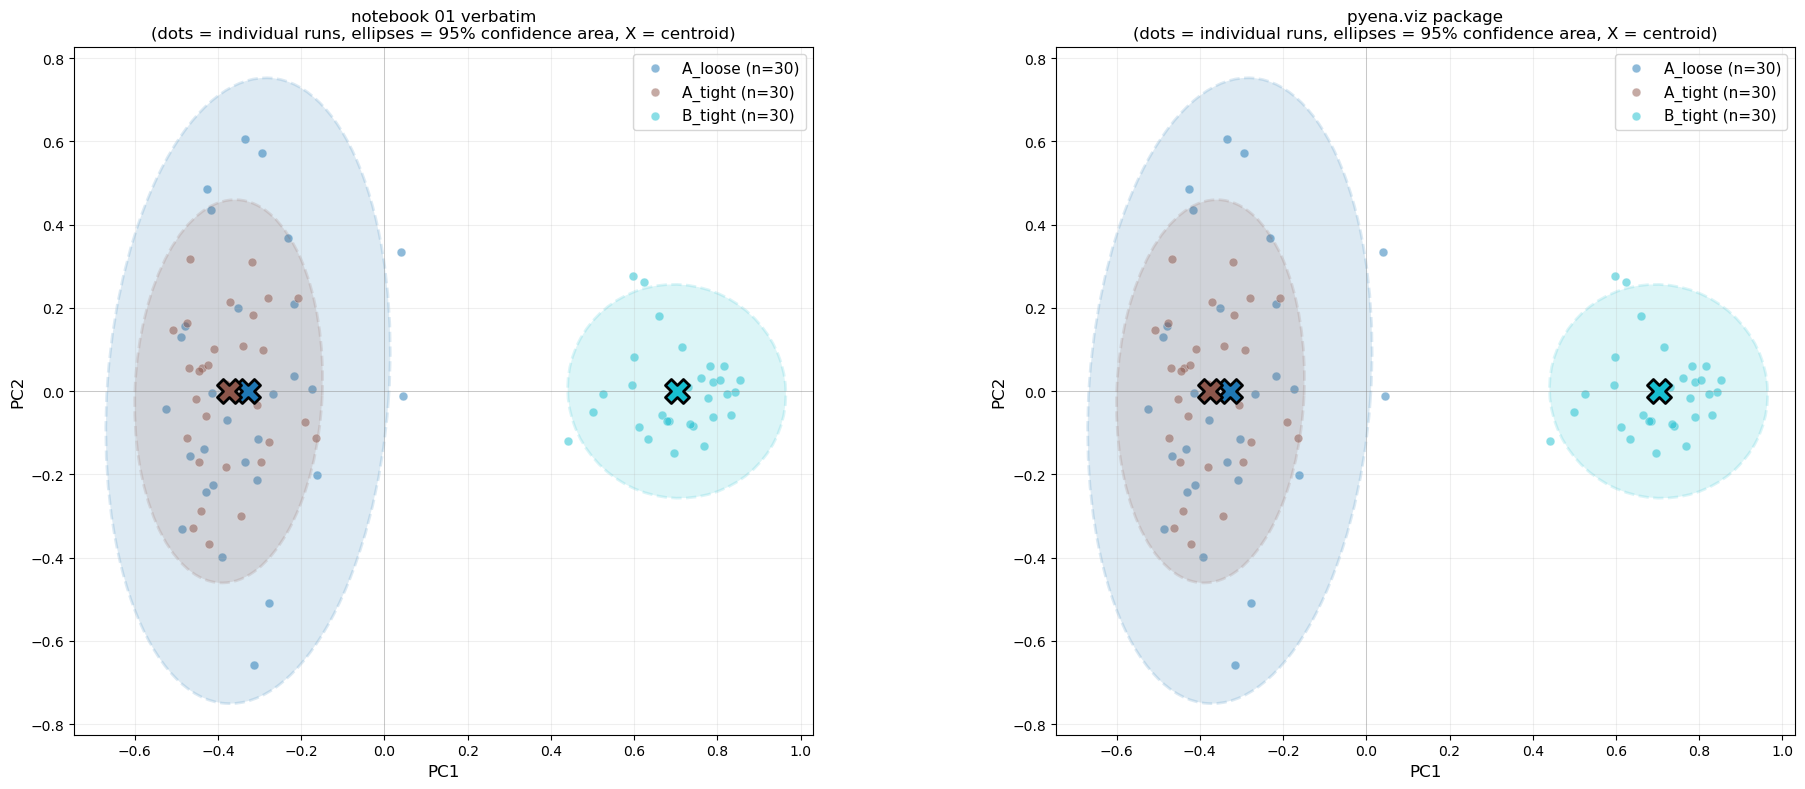

=== (a) Figure 구조 비교 ===
  scatter 그룹 수: nb01=3, pkg=3
  centroid 수:    nb01=3, pkg=3
  ellipse 수:     nb01=3, pkg=3

  scatter 좌표  max |Δ|: 0.00e+00
  centroid 좌표 max |Δ|: 0.00e+00
  ellipse center max |Δ|: 0.00e+00
  ellipse width  max |Δ|: 0.00e+00
  ellipse height max |Δ|: 0.00e+00
  ellipse angle  max |Δ|: 0.00e+00

=== (b) 95% Ellipse 수학 검증 ===
  χ²(0.95, df=2) = 5.991465

  --- A_loose ---
    center : drawn=[-0.3278789   0.00090481], formula=[-0.3278789   0.00090481], |Δ|=0.00e+00
    width  : drawn=1.506938, formula=1.506938, |Δ|=0.00e+00
    height : drawn=0.676634, formula=0.676634, |Δ|=0.00e+00
    angle  : drawn=85.859271, formula=85.859271, |Δ|=0.00e+00
  --- A_tight ---
    center : drawn=[-0.37448897 -0.00045241], formula=[-0.37448897 -0.00045241], |Δ|=0.00e+00
    width  : drawn=0.921547, formula=0.921547, |Δ|=0.00e+00
    height : drawn=0.450309, formula=0.450309, |Δ|=0.00e+00
    angle  : drawn=87.464943, formula=87.464943, |Δ|=0.00e+00
  --- B_tight ---
    center :

In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import chi2

for mod in list(sys.modules):
    if mod.startswith('pyena'):
        del sys.modules[mod]

from pyena.viz.plots import plot_reproducibility

# 입력: MR 검증된 좌표 (90 units, 3 groups)
with open(PROJECT_ROOT / 'tests/data/mr_validation_results.pkl', 'rb') as f:
    mr_ref = pickle.load(f)
points_input = mr_ref['pyena_mr_points']
labels_input = mr_ref['group_labels']


# === notebook 01 verbatim 함수 ===
def plot_reproducibility_NB01(points, group_labels, ax=None,
                                colors=None, show_ellipse=True,
                                title='ENA Space: Reproducibility Visualization'):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 8))
    group_labels = np.array(group_labels)
    groups = np.unique(group_labels)
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(groups)))
    for g, color in zip(groups, colors):
        mask = group_labels == g
        pts = points[mask]
        ax.scatter(pts[:, 0], pts[:, 1], s=40, alpha=0.5,
                   color=color, label=f'{g} (n={mask.sum()})',
                   edgecolor='white', linewidth=0.5)
        centroid = pts.mean(axis=0)
        ax.scatter(centroid[0], centroid[1], s=300, marker='X',
                   color=color, edgecolor='black', linewidth=2, zorder=5)
        if show_ellipse and len(pts) >= 3:
            cov = np.cov(pts.T)
            eigenvals, eigenvecs = np.linalg.eigh(cov)
            order = eigenvals.argsort()[::-1]
            eigenvals = eigenvals[order]
            eigenvecs = eigenvecs[:, order]
            angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
            chi2_val = chi2.ppf(0.95, df=2)
            width = 2 * np.sqrt(chi2_val * eigenvals[0])
            height = 2 * np.sqrt(chi2_val * eigenvals[1])
            ellipse = Ellipse(centroid, width, height, angle=angle,
                              facecolor=color, alpha=0.15, edgecolor=color,
                              linewidth=2, linestyle='--')
            ax.add_patch(ellipse)
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.set_xlabel('PC1', fontsize=12)
    ax.set_ylabel('PC2', fontsize=12)
    ax.set_title(f'{title}\n(dots = individual runs, ellipses = 95% confidence area, X = centroid)',
                 fontsize=12)
    ax.legend(loc='best', fontsize=11)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    return ax


# 두 그림 그리기
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
ax_nb01 = plot_reproducibility_NB01(points_input, labels_input, ax=axes[0])
ax_nb01.set_title('notebook 01 verbatim\n' + ax_nb01.get_title().split('\n', 1)[1])

ax_pkg = plot_reproducibility(points_input, labels_input, ax=axes[1])
ax_pkg.set_title('pyena.viz package\n' + ax_pkg.get_title().split('\n', 1)[1])
plt.tight_layout()
plt.show()


# === Figure 객체 구조 추출 ===
def extract_plot_structure(ax):
    """ax에서 scatter 좌표, centroid 좌표, ellipse 파라미터를 추출."""
    scatters = []  # (n_points, xy_array)
    centroids = []
    ellipses = []

    for coll in ax.collections:
        offsets = coll.get_offsets()
        # centroid는 1점만, scatter는 여러 점
        if len(offsets) == 1:
            centroids.append(np.array(offsets[0]))
        else:
            scatters.append(np.array(offsets))

    for patch in ax.patches:
        if isinstance(patch, Ellipse):
            ellipses.append({
                'center': np.array(patch.get_center()),
                'width': patch.get_width(),
                'height': patch.get_height(),
                'angle': patch.angle,
            })
    return scatters, centroids, ellipses


nb01_sc, nb01_c, nb01_e = extract_plot_structure(ax_nb01)
pkg_sc, pkg_c, pkg_e = extract_plot_structure(ax_pkg)

# === (a) 구조 비교 ===
print("=== (a) Figure 구조 비교 ===")
print(f"  scatter 그룹 수: nb01={len(nb01_sc)}, pkg={len(pkg_sc)}")
print(f"  centroid 수:    nb01={len(nb01_c)}, pkg={len(pkg_c)}")
print(f"  ellipse 수:     nb01={len(nb01_e)}, pkg={len(pkg_e)}")
print()

# 좌표/파라미터 max diff
max_sc_diff = max(np.abs(np.array(a) - np.array(b)).max()
                  for a, b in zip(nb01_sc, pkg_sc))
max_c_diff = max(np.abs(a - b).max() for a, b in zip(nb01_c, pkg_c))
max_e_center_diff = max(np.abs(a['center'] - b['center']).max() for a, b in zip(nb01_e, pkg_e))
max_e_width_diff = max(abs(a['width'] - b['width']) for a, b in zip(nb01_e, pkg_e))
max_e_height_diff = max(abs(a['height'] - b['height']) for a, b in zip(nb01_e, pkg_e))
max_e_angle_diff = max(abs(a['angle'] - b['angle']) for a, b in zip(nb01_e, pkg_e))

print(f"  scatter 좌표  max |Δ|: {max_sc_diff:.2e}")
print(f"  centroid 좌표 max |Δ|: {max_c_diff:.2e}")
print(f"  ellipse center max |Δ|: {max_e_center_diff:.2e}")
print(f"  ellipse width  max |Δ|: {max_e_width_diff:.2e}")
print(f"  ellipse height max |Δ|: {max_e_height_diff:.2e}")
print(f"  ellipse angle  max |Δ|: {max_e_angle_diff:.2e}")

# === (b) 95% Ellipse 수학 검증 ===
print()
print("=== (b) 95% Ellipse 수학 검증 ===")
chi2_val = chi2.ppf(0.95, df=2)
print(f"  χ²(0.95, df=2) = {chi2_val:.6f}")
print()

for g in np.unique(labels_input):
    pts_g = points_input[labels_input == g]
    cov = np.cov(pts_g.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    angle_expected = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width_expected = 2 * np.sqrt(chi2_val * eigvals[0])
    height_expected = 2 * np.sqrt(chi2_val * eigvals[1])
    center_expected = pts_g.mean(axis=0)

    # 패키지가 그린 ellipse 찾기 (그룹 순서대로)
    g_idx = list(np.unique(labels_input)).index(g)
    pkg_el = pkg_e[g_idx]

    print(f"  --- {g} ---")
    print(f"    center : drawn={pkg_el['center']}, formula={center_expected}, |Δ|={np.abs(pkg_el['center']-center_expected).max():.2e}")
    print(f"    width  : drawn={pkg_el['width']:.6f}, formula={width_expected:.6f}, |Δ|={abs(pkg_el['width']-width_expected):.2e}")
    print(f"    height : drawn={pkg_el['height']:.6f}, formula={height_expected:.6f}, |Δ|={abs(pkg_el['height']-height_expected):.2e}")
    print(f"    angle  : drawn={pkg_el['angle']:.6f}, formula={angle_expected:.6f}, |Δ|={abs(pkg_el['angle']-angle_expected):.2e}")

In [19]:
%%writefile ../src/pyena/api.py
"""scikit-learn 스타일 ENA estimator — pyena 패키지의 메인 entry point.

기본 사용법
-----------
    from pyena import ENA
    
    # SVD 좌표
    ena = ENA(codes=['c1','c2','c3'], window_size=4)
    ena.fit(df)
    coords = ena.transform(df)        # 또는 ena.coords_
    
    # Means rotation (그룹 비교용)
    ena = ENA(codes=codes, rotation='means', mr_groups=('A', 'B'))
    ena.fit(df)                       # df에 'group' 컬럼 필요
    ena.plot()
    ena.compare(axis='x')
    ena.reproducibility()

학습된 속성 (sklearn 컨벤션: `_` 접미사)
-----------------------------------------
    av_                : (n_units, n_pairs) — rENA-exact 인접 벡터
    av_normalized_     : (n_units, n_pairs) — sphere-normalized
    av_centered_       : (n_units, n_pairs) — centered (학습 mean 기준)
    mean_              : (n_pairs,)
    components_        : (n_components, n_pairs) — coords = centered @ components_.T
    singular_values_   : (n_components,) — SVD일 때만; MR이면 None
    rotation_matrix_   : (n_pairs, n_pairs) — MR일 때만; SVD이면 None
    mr_groups_used_    : (str, str) — MR일 때 회전 축 정의 그룹
    coords_            : (n_units, n_components) — 학습 데이터의 좌표
    unit_ids_, group_ids_, codes_, n_features_in_
"""

from __future__ import annotations

import numpy as np
from sklearn.base import BaseEstimator

from pyena.core.adjacency import compute_all_avs
from pyena.core.normalize import sphere_normalize
from pyena.core.projection import svd_project, means_rotation

__all__ = ["ENA"]


class ENA(BaseEstimator):
    """rENA-exact Epistemic Network Analysis estimator (scikit-learn style).

    Parameters
    ----------
    codes : list of str
        코드(co-occurrence를 셀 대상) 컬럼 이름들.
    unit_col : str, default 'unit'
        ENA unit을 정의하는 컬럼.
    conversation_col : str, default 'conversation'
        대화 경계 (window가 이 경계를 넘지 않음).
    group_col : str, default 'group'
        그룹 라벨이 들어있는 컬럼명 (rotation='means' 또는 편의 메서드에 사용).
    window_size : int, default 4
        Moving stanza window 크기.
    window_forward : int, default 0
        Forward lookahead (rENA 기본 0).
    binary : bool, default True
        Co-occurrence를 0/1로 캡 (rENA 기본).
    n_components : int, default 2
        유지할 component 수.
    rotation : {'svd', 'means'}, default 'svd'
        차원축소 후 회전 방식.
          - 'svd'   : 일반 SVD 주성분 (rENA의 기본 ena.svd에 해당)
          - 'means' : Means rotation (rENA의 ena.rotate.by.mean에 해당, mr_groups 필요)
    mr_groups : tuple of (group_a, group_b), default None
        rotation='means'일 때 X축(MR1)을 정의하는 두 그룹 라벨.
        diff = mean(group_a) - mean(group_b) 방향이 양의 X축.
    """

    def __init__(
        self,
        codes,
        unit_col='unit',
        conversation_col='conversation',
        group_col='group',
        window_size=4,
        window_forward=0,
        binary=True,
        n_components=2,
        rotation='svd',
        mr_groups=None,
    ):
        self.codes = codes
        self.unit_col = unit_col
        self.conversation_col = conversation_col
        self.group_col = group_col
        self.window_size = window_size
        self.window_forward = window_forward
        self.binary = binary
        self.n_components = n_components
        self.rotation = rotation
        self.mr_groups = mr_groups

    def _prep_df(self, X):
        """group_col이 기본값과 다르면 'group'으로 리네임 (compute_all_avs 호환)."""
        if self.group_col != 'group' and self.group_col in X.columns:
            return X.rename(columns={self.group_col: 'group'})
        return X

    def fit(self, X, y=None):
        """모델 학습: AV → 정규화 → 사영 → (옵션) MR.

        Parameters
        ----------
        X : pd.DataFrame
            Long-format utterance frame.
        y : ignored
            sklearn API 호환용. group_col을 통한 자동 추출 사용.

        Returns
        -------
        self
        """
        if self.rotation not in ('svd', 'means'):
            raise ValueError(f"rotation은 'svd' 또는 'means'. 받음: {self.rotation!r}")
        if self.rotation == 'means' and self.mr_groups is None:
            raise ValueError("rotation='means'이면 mr_groups=(group_a, group_b) 필요")

        df_use = self._prep_df(X)

        av, unit_ids, group_ids = compute_all_avs(
            df_use, self.codes,
            unit_col=self.unit_col,
            conversation_col=self.conversation_col,
            window_size=self.window_size,
            window_forward=self.window_forward,
            binary=self.binary,
        )

        av_n = sphere_normalize(av)
        proj = svd_project(av_n, n_components=self.n_components)

        if self.rotation == 'svd':
            self.coords_ = proj.coords
            self.components_ = proj.components
            self.singular_values_ = proj.singular_values
            self.rotation_matrix_ = None
            self.mr_groups_used_ = None
        else:  # 'means'
            if not group_ids:
                raise ValueError(
                    f"rotation='means'에는 '{self.group_col}' 컬럼이 X에 있어야 함"
                )
            group_arr = np.array(group_ids)
            ga, gb = self.mr_groups
            mr = means_rotation(proj.centered, group_arr, ga, gb)
            # MR은 full rotation을 반환 — 처음 n_components만 사용
            self.coords_ = mr.points[:, :self.n_components]
            # sklearn 컨벤션: coords = centered @ components_.T
            # MR에서: coords = centered @ rotation[:, :n], 따라서
            # components_ = rotation[:, :n].T → shape (n_components, n_features)
            self.components_ = mr.rotation[:, :self.n_components].T
            self.singular_values_ = None
            self.rotation_matrix_ = mr.rotation
            self.mr_groups_used_ = mr.groups_used

        # 공통 학습 속성
        self.av_ = av
        self.av_normalized_ = av_n
        self.av_centered_ = proj.centered
        self.mean_ = proj.mean
        self.unit_ids_ = unit_ids
        self.group_ids_ = group_ids
        self.codes_ = list(self.codes)
        self.n_features_in_ = av.shape[1]

        return self

    def transform(self, X):
        """새로운 데이터를 학습된 ENA 공간으로 사영.

        AV 계산 → sphere normalize → 학습 시점의 mean으로 centering → components_ 사영.
        """
        if not hasattr(self, 'mean_'):
            raise RuntimeError("transform 전에 fit을 먼저 호출하세요.")

        df_use = self._prep_df(X)
        av, _, _ = compute_all_avs(
            df_use, self.codes,
            unit_col=self.unit_col,
            conversation_col=self.conversation_col,
            window_size=self.window_size,
            window_forward=self.window_forward,
            binary=self.binary,
        )
        av_n = sphere_normalize(av)
        centered = av_n - self.mean_
        return centered @ self.components_.T

    def fit_transform(self, X, y=None):
        """fit 후 학습 데이터의 좌표 반환."""
        return self.fit(X, y).coords_

    # ===== 편의 메서드 =====

    def plot(self, ax=None, **kwargs):
        """ENA 공간 시각화 (group_ids_가 있어야 함)."""
        from pyena.viz.plots import plot_reproducibility
        if not self.group_ids_:
            raise ValueError(f"plot()에는 X에 '{self.group_col}' 컬럼이 필요")
        return plot_reproducibility(
            self.coords_, np.array(self.group_ids_), ax=ax, **kwargs
        )

    def compare(self, axis='x', n_permutations=10000, random_state=42):
        """두 그룹 비교 (Welch + Mann-Whitney + Permutation)."""
        from pyena.stats.compare import ena_group_comparison
        if not self.group_ids_:
            raise ValueError(f"compare()에는 X에 '{self.group_col}' 컬럼이 필요")
        return ena_group_comparison(
            self.coords_, np.array(self.group_ids_),
            axis=axis, n_permutations=n_permutations, random_state=random_state,
        )

    def reproducibility(self):
        """4가지 reproducibility 지표 (그룹별)."""
        from pyena.stats.reproducibility import reproducibility_metrics
        labels = np.array(self.group_ids_) if self.group_ids_ else None
        return reproducibility_metrics(self.coords_, labels)

Writing ../src/pyena/api.py


In [22]:
# __init__.py 직접 작성 (매직 사용하지 않음)
init_content = '''"""pyena: Python implementation of rENA-exact Epistemic Network Analysis."""

from pyena.api import ENA

__all__ = ["ENA"]
__version__ = "0.1.0.dev0"
'''

init_path = PROJECT_ROOT / 'src' / 'pyena' / '__init__.py'
init_path.write_text(init_content)

# 확인
print(f"쓴 파일: {init_path}")
print(f"파일 크기: {init_path.stat().st_size} bytes")
print()
print("=== 내용 ===")
print(init_path.read_text())

쓴 파일: /home/ubuntu/research/2026/research_pyena/src/pyena/__init__.py
파일 크기: 150 bytes

=== 내용 ===
"""pyena: Python implementation of rENA-exact Epistemic Network Analysis."""

from pyena.api import ENA

__all__ = ["ENA"]
__version__ = "0.1.0.dev0"



In [23]:
# 캐시 비우고 재import
for mod in list(sys.modules):
    if mod.startswith('pyena'):
        del sys.modules[mod]

from pyena import ENA

# 토이 데이터 로드
df = pd.read_csv(PROJECT_ROOT / 'tests/data/toy_data_n90.csv')
codes = ['Data', 'Theory', 'Question', 'Example', 'Critique']

# === 시나리오 1: SVD rotation ===
ena_svd = ENA(codes=codes, window_size=4, rotation='svd')
ena_svd.fit(df)

# pyena_reference (노트북 01의 SVD 결과)
with open(PROJECT_ROOT / 'tests/data/pyena_reference_output.pkl', 'rb') as f:
    ref01 = pickle.load(f)
# rena_reference (노트북 02의 rENA-exact AV)
with open(PROJECT_ROOT / 'tests/data/rena_validation_results.pkl', 'rb') as f:
    ref02 = pickle.load(f)
# mr_validation (노트북 02 후속)
with open(PROJECT_ROOT / 'tests/data/mr_validation_results.pkl', 'rb') as f:
    mr_ref = pickle.load(f)

# === SVD 검증 ===
print("=== 시나리오 1: ENA(rotation='svd') ===")
print(f"  av_              shape: {ena_svd.av_.shape}")
print(f"  av_normalized_   shape: {ena_svd.av_normalized_.shape}")
print(f"  av_centered_     shape: {ena_svd.av_centered_.shape}")
print(f"  coords_          shape: {ena_svd.coords_.shape}")
print(f"  components_      shape: {ena_svd.components_.shape}")
print(f"  singular_values_: {ena_svd.singular_values_}")
print(f"  rotation_matrix_: {ena_svd.rotation_matrix_}")
print()

# AV는 rENA-exact reference와 비교
diff_av = np.abs(ena_svd.av_ - ref02['pyena_avs']).max()
# normalized + centered는 pyena_ref와 비교 (이게 노트북 01 흐름)
# 단, pyena_ref는 combinations-order AV 기반이라 직접 비교 불가
# 대신 우리 ENA 자체의 일관성 확인: av_n = av_/||av_||, centered = av_n - mean
av_n_check = np.array([row/np.linalg.norm(row) if np.linalg.norm(row)>0 else row 
                       for row in ena_svd.av_])
diff_norm_internal = np.abs(av_n_check - ena_svd.av_normalized_).max()
diff_centered_internal = np.abs((ena_svd.av_normalized_ - ena_svd.mean_) - ena_svd.av_centered_).max()

# SVD coords는 mr_validation의 centered_input 기반 SVD와 일치해야 함
# 우리 centered와 mr_ref의 centered_input이 같은가? (둘 다 rENA-exact AV → sphere norm → center)
diff_centered_vs_mr = np.abs(ena_svd.av_centered_ - mr_ref['centered_input']).max()

# coords = centered @ Vt.T (n_components=2)
# pyena_reference의 points_2d는 동일 알고리즘이지만 AV가 다른 순서/스케일이라 직접 비교 불가
# 대신 sign-aligned 비교
def align_sign(a, b):
    out = a.copy()
    for k in range(a.shape[1]):
        if np.dot(a[:, k], b[:, k]) < 0:
            out[:, k] = -a[:, k]
    return out

# centered_matrix가 mr_validation과 같다면, 거기 SVD 결과는 일반 SVD2 = 노트북 02의 검증 단계와 같아야
U, S, Vt = np.linalg.svd(mr_ref['centered_input'], full_matrices=False)
expected_svd_coords = mr_ref['centered_input'] @ Vt[:2].T
coords_signed = align_sign(ena_svd.coords_, expected_svd_coords)
diff_coords = np.abs(coords_signed - expected_svd_coords).max()

print(f"  AV vs rENA-exact:           max |Δ| = {diff_av:.2e}")
print(f"  normalized 내부 일관성:      max |Δ| = {diff_norm_internal:.2e}")
print(f"  centered 내부 일관성:        max |Δ| = {diff_centered_internal:.2e}")
print(f"  centered vs mr_ref input:   max |Δ| = {diff_centered_vs_mr:.2e}")
print(f"  SVD coords (sign-aligned):  max |Δ| = {diff_coords:.2e}")

# === 시나리오 2: Means rotation ===
print()
print("=== 시나리오 2: ENA(rotation='means', mr_groups=('A_tight','B_tight')) ===")
ena_mr = ENA(codes=codes, window_size=4, rotation='means',
             mr_groups=('A_tight', 'B_tight'))
ena_mr.fit(df)

print(f"  coords_          shape: {ena_mr.coords_.shape}")
print(f"  rotation_matrix_ shape: {ena_mr.rotation_matrix_.shape}")
print(f"  mr_groups_used_:  {ena_mr.mr_groups_used_}")
print()

# MR coords는 mr_validation의 pyena_mr_points와 sign-aligned 일치해야
mr_signed = align_sign(ena_mr.coords_, mr_ref['pyena_mr_points'])
# mr_ref['pyena_mr_points']는 (90, 2) MR1, SVD2
diff_mr = np.abs(mr_signed - mr_ref['pyena_mr_points']).max()

# rENA와 직접 비교 (mr_ref['rena_mr_points'])
mr_signed_vs_rena = align_sign(ena_mr.coords_, mr_ref['rena_mr_points'])
diff_mr_vs_rena = np.abs(mr_signed_vs_rena - mr_ref['rena_mr_points']).max()

print(f"  MR coords vs mr_ref pyena:  max |Δ| = {diff_mr:.2e}")
print(f"  MR coords vs rENA MR1/SVD2: max |Δ| = {diff_mr_vs_rena:.2e}")

# === 편의 메서드 동작 확인 ===
print()
print("=== 편의 메서드 동작 확인 ===")
print()
print("ena_mr.compare(axis='x'):")
cmp = ena_mr.compare(axis='x')
print(f"  Welch t = {cmp['welch_t']:.4f}, p = {cmp['welch_p']:.2e}")
print(f"  Cohen's d = {cmp['cohens_d']:.4f}")
print()
print("ena_mr.reproducibility():")
print(ena_mr.reproducibility().round(4).to_string())

# === fit_transform / transform 검증 ===
print()
print("=== transform 일관성 검증 ===")
coords_via_transform = ena_svd.transform(df)
diff_ft = np.abs(coords_via_transform - ena_svd.coords_).max()
print(f"  ena.transform(X_fit) == ena.coords_: max |Δ| = {diff_ft:.2e}")

ena_ft = ENA(codes=codes, window_size=4, rotation='svd')
coords_ft = ena_ft.fit_transform(df)
diff_ft2 = np.abs(coords_ft - ena_svd.coords_).max()
print(f"  fit_transform vs fit().coords_:     max |Δ| = {diff_ft2:.2e}")

=== 시나리오 1: ENA(rotation='svd') ===
  av_              shape: (90, 10)
  av_normalized_   shape: (90, 10)
  av_centered_     shape: (90, 10)
  coords_          shape: (90, 2)
  components_      shape: (2, 10)
  singular_values_: [4.84110933 2.02001208]
  rotation_matrix_: None

  AV vs rENA-exact:           max |Δ| = 0.00e+00
  normalized 내부 일관성:      max |Δ| = 0.00e+00
  centered 내부 일관성:        max |Δ| = 0.00e+00
  centered vs mr_ref input:   max |Δ| = 0.00e+00
  SVD coords (sign-aligned):  max |Δ| = 0.00e+00

=== 시나리오 2: ENA(rotation='means', mr_groups=('A_tight','B_tight')) ===
  coords_          shape: (90, 2)
  rotation_matrix_ shape: (10, 10)
  mr_groups_used_:  ('A_tight', 'B_tight')

  MR coords vs mr_ref pyena:  max |Δ| = 0.00e+00
  MR coords vs rENA MR1/SVD2: max |Δ| = 3.68e-16

=== 편의 메서드 동작 확인 ===

ena_mr.compare(axis='x'):


ValueError: 두 그룹 비교만 지원. 받은 그룹: [np.str_('A_loose'), np.str_('A_tight'), np.str_('B_tight')]

In [24]:
# api.py의 compare 메서드만 패치 (간단한 in-place 수정)
api_path = PROJECT_ROOT / 'src' / 'pyena' / 'api.py'
content = api_path.read_text()

old_compare = '''    def compare(self, axis='x', n_permutations=10000, random_state=42):
        """두 그룹 비교 (Welch + Mann-Whitney + Permutation)."""
        from pyena.stats.compare import ena_group_comparison
        if not self.group_ids_:
            raise ValueError(f"compare()에는 X에 '{self.group_col}' 컬럼이 필요")
        return ena_group_comparison(
            self.coords_, np.array(self.group_ids_),
            axis=axis, n_permutations=n_permutations, random_state=random_state,
        )'''

new_compare = '''    def compare(self, axis='x', groups=None, n_permutations=10000, random_state=42):
        """두 그룹 비교 (Welch + Mann-Whitney + Permutation).

        Parameters
        ----------
        axis : {'x', 'y'}, default 'x'
        groups : tuple of (group_a, group_b), optional
            비교할 두 그룹. None이면 mr_groups_used_ 사용 (rotation='means'일 때).
        n_permutations, random_state :
            ena_group_comparison에 전달.
        """
        from pyena.stats.compare import ena_group_comparison
        if not self.group_ids_:
            raise ValueError(f"compare()에는 X에 '{self.group_col}' 컬럼이 필요")
        if groups is None:
            if self.mr_groups_used_ is None:
                raise ValueError(
                    "그룹이 2개 초과면 groups=('A','B')를 명시. "
                    "rotation='means'면 mr_groups_used_ 자동 사용."
                )
            groups = self.mr_groups_used_
        labels = np.array(self.group_ids_)
        mask = np.isin(labels, groups)
        return ena_group_comparison(
            self.coords_[mask], labels[mask],
            axis=axis, n_permutations=n_permutations, random_state=random_state,
        )'''

content = content.replace(old_compare, new_compare)
api_path.write_text(content)
print(f"패치 완료: {api_path}")
print(f"파일 크기: {api_path.stat().st_size} bytes")

패치 완료: /home/ubuntu/research/2026/research_pyena/src/pyena/api.py
파일 크기: 9334 bytes


In [25]:
for mod in list(sys.modules):
    if mod.startswith('pyena'):
        del sys.modules[mod]
from pyena import ENA

df = pd.read_csv(PROJECT_ROOT / 'tests/data/toy_data_n90.csv')
codes = ['Data', 'Theory', 'Question', 'Example', 'Critique']

ena_mr = ENA(codes=codes, window_size=4, rotation='means',
             mr_groups=('A_tight', 'B_tight'))
ena_mr.fit(df)

print("=== compare() — mr_groups_used_ 자동 사용 ===")
cmp = ena_mr.compare(axis='x')
print(f"  Welch t = {cmp['welch_t']:.4f}, p = {cmp['welch_p']:.2e}")
print(f"  Cohen's d = {cmp['cohens_d']:.4f}")
print(f"  n1, n2 = {cmp['n1']}, {cmp['n2']}  (A_tight + B_tight만 비교)")
print()

print("=== compare(groups=('A_tight','A_loose')) — 명시 ===")
cmp2 = ena_mr.compare(axis='x', groups=('A_tight', 'A_loose'))
print(f"  Welch t = {cmp2['welch_t']:.4f}, p = {cmp2['welch_p']:.2e}")
print(f"  n1, n2 = {cmp2['n1']}, {cmp2['n2']}")
print()

print("=== reproducibility() (그룹 3개 모두) ===")
print(ena_mr.reproducibility().round(4).to_string())
print()

print("=== transform 일관성 ===")
coords_via_transform = ena_mr.transform(df)
diff_ft = np.abs(coords_via_transform - ena_mr.coords_).max()
print(f"  transform(X_fit) == coords_:  max |Δ| = {diff_ft:.2e}")

=== compare() — mr_groups_used_ 자동 사용 ===
  Welch t = -41.7216, p = 2.78e-44
  Cohen's d = -10.7725
  n1, n2 = 30, 30  (A_tight + B_tight만 비교)

=== compare(groups=('A_tight','A_loose')) — 명시 ===
  Welch t = 1.5253, p = 1.33e-01
  n1, n2 = 30, 30

=== reproducibility() (그룹 3개 모두) ===
            n  centroid_x  centroid_y  centroid_dispersion_mean  centroid_dispersion_std  pairwise_distance_mean  pairwise_distance_max  ellipse_95_area  convex_hull_area
A_loose  30.0     -0.3279      0.0009                    0.2863                   0.1677                  0.4141                 1.2630           0.8008            0.4609
A_tight  30.0     -0.3745     -0.0005                    0.1844                   0.0917                  0.2616                 0.6851           0.3259            0.1688
B_tight  30.0      0.7024     -0.0005                    0.1331                   0.0635                  0.1862                 0.4427           0.2115            0.1033

=== transform 일관성 ===
  transfo

In [26]:
%%writefile ../src/pyena/core/adjacency.py
"""Adjacency vector construction, rENA-exact.

This module mirrors the C++ source of rENA 0.3.1 (``vector_to_ut`` and
``ref_window_df`` in ``rENA/src/ena.cpp``). The implementation has been
verified bit-for-bit against rENA on a 90-unit toy dataset
(900/900 cells match, max absolute difference = 0).

References
----------
.. [1] Marquart, C. L., Swiecki, Z., Collier, W., Eagan, B., Woodward, R.,
       & Shaffer, D. W. (2021). rENA: Epistemic Network Analysis (R package
       version 0.3.1).
"""

from __future__ import annotations

import numpy as np
import pandas as pd

__all__ = [
    "compute_all_avs",
    "get_rena_pair_order",
    "ref_window_df",
    "vector_to_ut",
]


def vector_to_ut(v):
    """Vectorize the strict upper triangle of an outer product.

    Reimplementation of rENA's ``vector_to_ut`` (``ena.cpp`` lines 142-155).
    Given a code-count vector ``v`` of length ``n``, returns the strict upper
    triangle of the outer product ``v v^T`` in column-major order, which is
    the canonical ordering used by rENA throughout the pipeline.

    Parameters
    ----------
    v : array-like of shape (n,)
        Code-count vector (typically the column-sum of a stanza window).

    Returns
    -------
    np.ndarray of shape (n * (n - 1) / 2,)
        Strict upper-triangular entries of ``v v^T`` in rENA's column-major
        ordering.

    Notes
    -----
    The traversal order is::

        for i in range(2, n + 1):
            for j in range(0, i - 1):
                yield v[j] * v[i - 1]

    This matches rENA's C++ implementation exactly. Changing the order would
    break parity with rENA.
    """
    n = len(v)
    out = []
    for i in range(2, n + 1):
        for j in range(0, i - 1):
            out.append(v[j] * v[i - 1])
    return np.array(out, dtype=float)


def get_rena_pair_order(codes):
    """Return the code-pair ordering used by ``vector_to_ut``.

    Parameters
    ----------
    codes : list of str
        Code names in their original order.

    Returns
    -------
    list of tuple of (str, str)
        Code pairs in the same order as the entries returned by
        ``vector_to_ut``. Useful for labelling adjacency-vector columns.
    """
    pairs = []
    n = len(codes)
    for i in range(2, n + 1):
        for j in range(0, i - 1):
            pairs.append((codes[j], codes[i - 1]))
    return pairs


def ref_window_df(code_matrix, window_size=4, window_forward=0, binary=True):
    """Compute per-row adjacency vectors using rENA's moving-stanza window.

    Faithful reimplementation of rENA's ``ref_window_df`` (``ena.cpp`` lines
    205-311), including the head/tail subtraction trick that yields each
    focal row's stanza window co-occurrence without recomputing from scratch.

    Parameters
    ----------
    code_matrix : np.ndarray of shape (n_rows, n_codes)
        Binary code-presence matrix. Each row is one utterance, each column
        one code.
    window_size : int, default 4
        Size of the moving stanza window (focal row + lookback).
    window_forward : int, default 0
        Forward lookahead beyond the focal row. rENA's default is 0.
    binary : bool, default True
        If True, co-occurrence counts are clipped to 0/1 (rENA default).
        If False, raw counts are returned.

    Returns
    -------
    np.ndarray of shape (n_rows, n_pairs)
        Per-row adjacency vectors in rENA pair order, where
        ``n_pairs = n_codes * (n_codes - 1) / 2``.
    """
    df_rows, df_cols = code_matrix.shape
    n_pairs = (df_cols * (df_cols + 1)) // 2 - df_cols
    df_co_occurred = np.zeros((df_rows, n_pairs))

    for row in range(df_rows):
        earliest_row = max(0, row - (window_size - 1))
        last_row = min(df_rows - 1, row + window_forward)

        curr_rows = code_matrix[earliest_row:last_row + 1]
        curr_rows_summed = curr_rows.sum(axis=0)
        to_ut = vector_to_ut(curr_rows_summed)

        # Head subtraction: remove contributions from rows before the focal
        curr_rows_n = curr_rows.shape[0]
        if curr_rows_n > 0 and window_size > 1 and row - 1 >= 0:
            head_rows_count = curr_rows_n - 1 - window_forward
            if head_rows_count > 0:
                curr_rows_refs = curr_rows[:head_rows_count]
                curr_row_refs_summed = curr_rows_refs.sum(axis=0)
                to_ut_refs = vector_to_ut(curr_row_refs_summed)
                to_ut = to_ut - to_ut_refs

        # Tail subtraction: remove forward-lookahead contributions
        if curr_rows_n > 0 and window_forward > 0 and last_row <= df_rows - 1:
            tail_rows_to_use = last_row - row
            if tail_rows_to_use > 0:
                curr_rows_refs = curr_rows[-tail_rows_to_use:]
                curr_row_refs_summed = curr_rows_refs.sum(axis=0)
                to_ut_refs = vector_to_ut(curr_row_refs_summed)
                to_ut = to_ut - to_ut_refs

        df_co_occurred[row] = to_ut

    if binary:
        df_co_occurred = (df_co_occurred > 0).astype(float)

    return df_co_occurred


def compute_all_avs(
    df,
    codes,
    unit_col='unit',
    conversation_col='conversation',
    window_size=4,
    window_forward=0,
    binary=True,
):
    """Compute per-unit adjacency vectors over all stanza windows.

    For each unit, the function iterates over its conversations, applies the
    rENA-exact moving-stanza window within each conversation (windows do not
    cross conversation boundaries), and sums per-row adjacency vectors into a
    single per-unit vector.

    Parameters
    ----------
    df : pd.DataFrame
        Long-format utterance table. Must be sortable by a ``'turn'`` column
        within each unit, and must contain the columns listed in ``codes``,
        plus ``unit_col`` and ``conversation_col``.
    codes : list of str
        Code column names. Their order is preserved in the output AV columns.
    unit_col : str, default 'unit'
        Column name defining ENA units.
    conversation_col : str, default 'conversation'
        Column name defining conversation boundaries.
    window_size : int, default 4
        Stanza window size, passed to ``ref_window_df``.
    window_forward : int, default 0
        Forward lookahead, passed to ``ref_window_df``.
    binary : bool, default True
        Whether to clip co-occurrence counts to 0/1, passed to ``ref_window_df``.

    Returns
    -------
    avs : np.ndarray of shape (n_units, n_pairs)
        Per-unit adjacency vectors in rENA pair order.
    unit_ids : list
        Unit identifiers in the same order as ``avs`` rows.
    group_ids : list
        Group labels per unit if ``'group'`` is a column in ``df``; otherwise
        an empty list.
    """
    all_avs = []
    unit_ids = []
    group_ids = []
    has_group = 'group' in df.columns

    for unit_id in df[unit_col].unique():
        unit_data = (
            df[df[unit_col] == unit_id].sort_values('turn').reset_index(drop=True)
        )
        n_codes = len(codes)
        unit_av = np.zeros((n_codes * (n_codes + 1)) // 2 - n_codes)

        for conv in unit_data[conversation_col].unique():
            conv_data = (
                unit_data[unit_data[conversation_col] == conv]
                .sort_values('turn')
                .reset_index(drop=True)
            )
            cm = conv_data[codes].values
            co_occurred = ref_window_df(
                cm,
                window_size=window_size,
                window_forward=window_forward,
                binary=binary,
            )
            unit_av += co_occurred.sum(axis=0)

        all_avs.append(unit_av)
        unit_ids.append(unit_id)
        if has_group:
            group_ids.append(unit_data['group'].iloc[0])

    return np.array(all_avs), unit_ids, group_ids

Overwriting ../src/pyena/core/adjacency.py


In [27]:
for mod in list(sys.modules):
    if mod.startswith('pyena'):
        del sys.modules[mod]

from pyena.core.adjacency import compute_all_avs

df = pd.read_csv(PROJECT_ROOT / 'tests/data/toy_data_n90.csv')
codes = ['Data', 'Theory', 'Question', 'Example', 'Critique']

with open(PROJECT_ROOT / 'tests/data/rena_validation_results.pkl', 'rb') as f:
    rena_ref = pickle.load(f)

avs, unit_ids, _ = compute_all_avs(df, codes, window_size=4)
diff = np.abs(avs - rena_ref['pyena_avs']).max()
print(f"adjacency.py 영어화 후 회귀: max |Δ| = {diff:.2e}")
print(f"docstring 확인 (첫 10줄):")
import pyena.core.adjacency as adj
print(adj.__doc__[:300] + '...')

adjacency.py 영어화 후 회귀: max |Δ| = 0.00e+00
docstring 확인 (첫 10줄):
Adjacency vector construction, rENA-exact.

This module mirrors the C++ source of rENA 0.3.1 (``vector_to_ut`` and
``ref_window_df`` in ``rENA/src/ena.cpp``). The implementation has been
verified bit-for-bit against rENA on a 90-unit toy dataset
(900/900 cells match, max absolute difference = 0).

R...


In [28]:
%%writefile ../src/pyena/core/normalize.py
"""Sphere normalization of adjacency vectors.

Each adjacency vector is divided by its L2 norm, projecting it onto the unit
hypersphere. Zero-norm vectors are returned unchanged, following rENA's
convention.
"""

from __future__ import annotations

import numpy as np

__all__ = ["sphere_normalize"]


def sphere_normalize(av):
    """L2-normalize each vector to unit length.

    Parameters
    ----------
    av : np.ndarray
        Either a single adjacency vector of shape ``(n_pairs,)`` or a
        stacked matrix of shape ``(n_units, n_pairs)``.

    Returns
    -------
    np.ndarray
        Same shape as the input. Each row (or the single vector) is rescaled
        to unit L2 norm. Rows whose L2 norm is exactly zero are returned
        unchanged, matching rENA's behaviour.
    """
    av = np.asarray(av, dtype=float)
    if av.ndim == 1:
        norm = np.linalg.norm(av)
        return av if norm == 0 else av / norm
    norms = np.linalg.norm(av, axis=1, keepdims=True)
    norms_safe = np.where(norms == 0, 1.0, norms)
    return av / norms_safe

Overwriting ../src/pyena/core/normalize.py


In [29]:
for mod in list(sys.modules):
    if mod.startswith('pyena'):
        del sys.modules[mod]

from pyena.core.normalize import sphere_normalize

with open(PROJECT_ROOT / 'tests/data/pyena_reference_output.pkl', 'rb') as f:
    ref01 = pickle.load(f)

normalized = sphere_normalize(ref01['av_matrix'])
diff = np.abs(normalized - ref01['normalized_matrix']).max()
print(f"normalize.py 영어화 후 회귀: max |Δ| = {diff:.2e}")

normalize.py 영어화 후 회귀: max |Δ| = 0.00e+00


In [30]:
%%writefile ../src/pyena/core/projection.py
"""SVD projection and rENA-exact means rotation.

Two dimensionality-reduction routines used downstream of sphere normalization:

  - ``svd_project``    : centering + thin SVD, returns coords, components,
                         singular values, and the centering vector.
  - ``means_rotation`` : faithful reimplementation of rENA's
                         ``ena.rotate.by.mean``, including the auxiliary
                         ``orthogonal_svd`` routine. Verified against rENA
                         0.3.1 at machine epsilon (max |Δ| ≈ 2e-16).
"""

from __future__ import annotations

from dataclasses import dataclass

import numpy as np

__all__ = [
    "MeansRotationResult",
    "ProjectionResult",
    "means_rotation",
    "orthogonal_svd",
    "svd_project",
]


@dataclass
class ProjectionResult:
    """Container for the output of :func:`svd_project`.

    Attributes
    ----------
    coords : np.ndarray of shape (n_units, n_components)
        Projected coordinates.
    components : np.ndarray of shape (n_components, n_features)
        The first ``n_components`` right-singular vectors (``Vt[:n_components]``).
    singular_values : np.ndarray of shape (n_components,)
        Top ``n_components`` singular values.
    mean : np.ndarray of shape (n_features,)
        Column-mean used for centering.
    centered : np.ndarray of shape (n_units, n_features)
        The centered input matrix, retained for downstream use and verification.
    """

    coords: np.ndarray
    components: np.ndarray
    singular_values: np.ndarray
    mean: np.ndarray
    centered: np.ndarray


@dataclass
class MeansRotationResult:
    """Container for the output of :func:`means_rotation`.

    Attributes
    ----------
    points : np.ndarray of shape (n_units, n_features)
        Rotated coordinates over all retained dimensions. The first column is
        ``MR1`` (the means-rotation axis), columns 2 onward are ``SVD2``,
        ``SVD3``, ... within the subspace orthogonal to ``MR1``.
    rotation : np.ndarray of shape (n_features, n_features)
        Full rotation matrix. ``points == centered @ rotation``.
    weights : np.ndarray of shape (n_features, 1)
        Unit vector defining the ``MR1`` axis (the normalized group-mean
        difference).
    groups_used : tuple
        ``(group_a, group_b)`` labels used to define the rotation axis.
    """

    points: np.ndarray
    rotation: np.ndarray
    weights: np.ndarray
    groups_used: tuple


def svd_project(normalized_matrix, n_components=2):
    """Center the input and project it onto its top singular components.

    Parameters
    ----------
    normalized_matrix : np.ndarray of shape (n_units, n_features)
        Output of :func:`pyena.core.normalize.sphere_normalize`.
    n_components : int, default 2
        Number of components to retain.

    Returns
    -------
    ProjectionResult
    """
    M = np.asarray(normalized_matrix, dtype=float)
    mean = M.mean(axis=0)
    centered = M - mean

    U, S, Vt = np.linalg.svd(centered, full_matrices=False)

    components = Vt[:n_components]
    singular_values = S[:n_components]
    coords = centered @ components.T

    return ProjectionResult(
        coords=coords,
        components=components,
        singular_values=singular_values,
        mean=mean,
        centered=centered,
    )


def orthogonal_svd(data, weights):
    """rENA-exact ``orthogonal_svd`` (``rENA/R/RotationSet.R``).

    Builds an orthonormal basis whose first ``ncol(weights)`` columns coincide
    with ``weights``, then runs an SVD inside the orthogonal complement and
    composes the result into a full rotation matrix.

    Parameters
    ----------
    data : np.ndarray of shape (n, p)
        Centered data matrix.
    weights : np.ndarray of shape (p, k)
        Axes to fix as the first ``k`` columns of the output rotation.
        For means rotation, ``k == 1``.

    Returns
    -------
    np.ndarray of shape (p, p)
        Full rotation matrix ``[weights | SVD-of-orthogonal-complement]``.
    """
    Q, _ = np.linalg.qr(weights, mode='complete')  # (p, p)
    k = weights.shape[1]

    # Project data into the subspace orthogonal to `weights`
    X_bar = data @ Q[:, k:]  # (n, p - k)

    # rENA uses prcomp(X_bar, scale=F), which centers by default.
    X_bar_centered = X_bar - X_bar.mean(axis=0)
    _, _, Vt = np.linalg.svd(X_bar_centered, full_matrices=False)
    V = Vt.T

    return np.hstack([Q[:, :k], Q[:, k:] @ V])


def means_rotation(centered_matrix, group_labels, group_a, group_b):
    """rENA-exact means rotation (``ena.rotate.by.mean``).

    Reimplements rENA 0.3.1's ``ena.rotate.by.mean`` (``rENA/R/RotationSet.R``)
    by reverse-engineering its R source and porting it to NumPy. Verified
    against rENA at machine epsilon on the included toy dataset
    (max |Δ| ≈ 2e-16).

    Algorithm:

      1. Re-center the input matrix (defensive; matches rENA's
         ``scale(data, scale=FALSE, center=TRUE)``).
      2. Compute the unit vector in the direction of
         ``mean(group_a) - mean(group_b)``; this becomes the ``MR1`` axis.
      3. Deflate the data along that axis.
      4. Apply :func:`orthogonal_svd` to build the full rotation matrix,
         keeping ``MR1`` as the first axis and using SVD on the orthogonal
         complement for the remaining axes.

    Parameters
    ----------
    centered_matrix : np.ndarray of shape (n_units, n_features)
        Sphere-normalized and centered adjacency-vector matrix.
    group_labels : array-like of shape (n_units,)
        Group label per unit.
    group_a, group_b : object
        The two group labels that define the ``MR1`` axis. The positive
        direction of ``MR1`` corresponds to ``mean(group_a) - mean(group_b)``.

    Returns
    -------
    MeansRotationResult

    Raises
    ------
    ValueError
        If either ``group_a`` or ``group_b`` is not present in
        ``group_labels``, or if the two group means are identical so that
        the rotation axis is undefined.
    """
    M = np.asarray(centered_matrix, dtype=float)
    labels = np.asarray(group_labels)

    if group_a not in labels or group_b not in labels:
        raise ValueError(
            f"group_a={group_a!r} and group_b={group_b!r} must both be present "
            f"in group_labels. Got: {sorted(set(labels.tolist()))}"
        )

    # rENA line 22: scale(data, scale=FALSE, center=TRUE)
    M = M - M.mean(axis=0)

    # rENA lines 39-44: unit vector in the direction of group-mean difference
    g1 = M[labels == group_a].mean(axis=0)
    g2 = M[labels == group_b].mean(axis=0)
    diff = g1 - g2
    norm = np.sqrt(np.sum(diff ** 2))
    if norm == 0:
        raise ValueError(
            "Group means are identical; means-rotation axis is undefined."
        )
    col_mean_diff_sq = diff / norm
    weights = col_mean_diff_sq[:, np.newaxis]

    # rENA lines 45-46: deflation
    deflated = M - (M @ weights) @ weights.T

    # rENA line 50: orthogonal_svd produces the full rotation matrix
    rotation = orthogonal_svd(deflated, weights)

    points = M @ rotation

    return MeansRotationResult(
        points=points,
        rotation=rotation,
        weights=weights,
        groups_used=(group_a, group_b),
    )

Overwriting ../src/pyena/core/projection.py


In [31]:
for mod in list(sys.modules):
    if mod.startswith('pyena'):
        del sys.modules[mod]

from pyena.core.projection import svd_project, means_rotation

with open(PROJECT_ROOT / 'tests/data/pyena_reference_output.pkl', 'rb') as f:
    ref01 = pickle.load(f)
with open(PROJECT_ROOT / 'tests/data/mr_validation_results.pkl', 'rb') as f:
    mr_ref = pickle.load(f)

def align_sign(a, b):
    out = a.copy()
    for k in range(a.shape[1]):
        if np.dot(a[:, k], b[:, k]) < 0:
            out[:, k] = -a[:, k]
    return out

# SVD
result = svd_project(ref01['normalized_matrix'], n_components=2)
coords_signed = align_sign(result.coords, ref01['points_2d'])
diff_svd = np.abs(coords_signed - ref01['points_2d']).max()

# MR
mr_result = means_rotation(
    mr_ref['centered_input'], mr_ref['group_labels'],
    group_a='A_tight', group_b='B_tight',
)
mr_signed = align_sign(mr_result.points[:, :2], mr_ref['rena_mr_points'])
diff_mr = np.abs(mr_signed - mr_ref['rena_mr_points']).max()

print(f"projection.py 영어화 후 회귀:")
print(f"  SVD coords  max |Δ| = {diff_svd:.2e}")
print(f"  MR coords   max |Δ| = {diff_mr:.2e}")

projection.py 영어화 후 회귀:
  SVD coords  max |Δ| = 0.00e+00
  MR coords   max |Δ| = 3.68e-16


In [32]:
%%writefile ../src/pyena/stats/compare.py
"""Group comparison on ENA coordinates.

Reports three complementary tests so that the user can choose the most
appropriate one for their sample-size and distributional regime:

  - Welch's t-test    : parametric, no equal-variance assumption.
  - Mann-Whitney U    : non-parametric, distribution-free.
  - Permutation test  : exact under the null, robust at small ``n``.

In addition the function reports Cohen's d (standardised effect size) and the
smallest achievable two-sided Mann-Whitney p-value at the given sample sizes,
which is useful for diagnosing under-powered designs.
"""

from __future__ import annotations

import warnings
from math import comb

import numpy as np
from scipy import stats

__all__ = ["ena_group_comparison"]


def ena_group_comparison(
    points,
    group_labels,
    axis='x',
    n_permutations=10000,
    random_state=42,
):
    """Compare two groups along one ENA axis using three statistical tests.

    Parameters
    ----------
    points : np.ndarray of shape (n_units, >= 2)
        ENA coordinates. ``axis='x'`` uses column 0, ``axis='y'`` uses column 1.
    group_labels : array-like of shape (n_units,)
        Group label per unit. Exactly two distinct labels are required.
    axis : {'x', 'y'}, default 'x'
        Which axis to test.
    n_permutations : int, default 10000
        Number of permutations used by the permutation test.
    random_state : int, default 42
        Seed for the permutation test's random number generator. Fixing it
        guarantees byte-for-byte reproducibility.

    Returns
    -------
    dict
        Results dictionary with the following keys:

        - ``axis``, ``n1``, ``n2``
        - ``g1_mean``, ``g1_std``, ``g2_mean``, ``g2_std``, ``observed_diff``
        - ``mannwhitney_U``, ``mannwhitney_p``, ``mannwhitney_min_possible_p``
        - ``welch_t``, ``welch_p``
        - ``permutation_p``, ``permutation_n``
        - ``cohens_d``

    Raises
    ------
    ValueError
        If ``group_labels`` does not contain exactly two distinct values.

    Warns
    -----
    UserWarning
        Emitted when either group has fewer than four units, since the
        Mann-Whitney U test cannot achieve p < 0.05 under those conditions.
    """
    axis_idx = 0 if axis == 'x' else 1
    groups = np.unique(group_labels)
    if len(groups) != 2:
        raise ValueError(
            f"Exactly two groups are required. Got: {list(groups)}"
        )

    group_labels = np.array(group_labels)
    g1_vals = points[group_labels == groups[0], axis_idx]
    g2_vals = points[group_labels == groups[1], axis_idx]
    n1, n2 = len(g1_vals), len(g2_vals)

    # Small-sample warning
    if min(n1, n2) < 4:
        warnings.warn(
            f"Small sample warning: n1={n1}, n2={n2}. "
            f"Mann-Whitney U cannot achieve p < 0.05 with fewer than four "
            f"units per group. Consider the permutation test or larger samples.",
            UserWarning,
        )

    # Standard tests
    u_stat, u_pval = stats.mannwhitneyu(g1_vals, g2_vals, alternative='two-sided')
    t_stat, t_pval = stats.ttest_ind(g1_vals, g2_vals, equal_var=False)

    # Permutation test
    observed_diff = g1_vals.mean() - g2_vals.mean()
    combined = np.concatenate([g1_vals, g2_vals])
    rng = np.random.default_rng(random_state)
    perm_diffs = np.zeros(n_permutations)
    for i in range(n_permutations):
        shuffled = rng.permutation(combined)
        perm_diffs[i] = shuffled[:n1].mean() - shuffled[n1:].mean()
    perm_pval = (np.abs(perm_diffs) >= np.abs(observed_diff)).mean()

    # Cohen's d (pooled standard deviation)
    pooled_std = np.sqrt(
        ((n1 - 1) * g1_vals.var(ddof=1) + (n2 - 1) * g2_vals.var(ddof=1))
        / (n1 + n2 - 2)
    )
    cohens_d = observed_diff / pooled_std if pooled_std > 0 else np.inf

    # Smallest achievable two-sided Mann-Whitney p-value at these sample sizes
    min_possible_p = 2 / comb(n1 + n2, n1)

    return {
        'axis': axis,
        'n1': n1, 'n2': n2,
        'g1_mean': g1_vals.mean(), 'g1_std': g1_vals.std(ddof=1),
        'g2_mean': g2_vals.mean(), 'g2_std': g2_vals.std(ddof=1),
        'observed_diff': observed_diff,
        'mannwhitney_U': u_stat, 'mannwhitney_p': u_pval,
        'mannwhitney_min_possible_p': min_possible_p,
        'welch_t': t_stat, 'welch_p': t_pval,
        'permutation_p': perm_pval,
        'permutation_n': n_permutations,
        'cohens_d': cohens_d,
    }

Overwriting ../src/pyena/stats/compare.py


In [33]:
for mod in list(sys.modules):
    if mod.startswith('pyena'):
        del sys.modules[mod]

from pyena.stats.compare import ena_group_comparison

with open(PROJECT_ROOT / 'tests/data/compare_reference.pkl', 'rb') as f:
    cmp_ref = pickle.load(f)

pkg_x = ena_group_comparison(
    cmp_ref['input_points'], cmp_ref['input_labels'],
    axis='x', n_permutations=10000, random_state=42,
)

# 모든 수치 필드 비교
max_diff = 0.0
for k, v in cmp_ref['result_x'].items():
    if isinstance(v, (int, float, np.integer, np.floating)):
        d = abs(pkg_x[k] - v)
        if d > max_diff:
            max_diff = d

print(f"compare.py 영어화 후 회귀: max |Δ| (X축, 모든 수치 필드) = {max_diff:.2e}")

compare.py 영어화 후 회귀: max |Δ| (X축, 모든 수치 필드) = 0.00e+00


In [34]:
%%writefile ../src/pyena/stats/reproducibility.py
"""Reproducibility metrics in ENA space.

Quantifies how tightly a set of units clusters in the projected ENA space.
For each group (or for the data as a whole), four indicators are computed:

  1. **Centroid dispersion** — mean (and standard deviation) of the distance
     from each unit to the group centroid. Low values indicate convergence.
  2. **Pairwise distance** — mean and maximum pairwise Euclidean distance
     between units.
  3. **95% confidence ellipse area** — area of the bivariate-normal
     confidence ellipse, computed as ``π · χ²(0.95, df=2) · √(λ₁ λ₂)`` where
     ``λ₁, λ₂`` are the eigenvalues of the sample covariance matrix.
  4. **Convex hull area** — area of the actual polygon spanned by the units
     (via ``scipy.spatial.ConvexHull``).

Lower values across all four indicators indicate higher reproducibility.
These metrics are designed for, but not limited to, LLM dialogue-path
analyses where the same prompt is run multiple times.
"""

from __future__ import annotations

import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist
from scipy.stats import chi2

__all__ = ["reproducibility_metrics"]


def reproducibility_metrics(points, group_labels=None):
    """Compute four reproducibility indicators, per group or overall.

    Parameters
    ----------
    points : np.ndarray of shape (n_units, 2)
        ENA two-dimensional coordinates.
    group_labels : array-like of shape (n_units,), optional
        If provided, metrics are computed per group. If ``None``, all rows
        are treated as a single group with index ``'all'``.

    Returns
    -------
    pd.DataFrame
        One row per group (or one row labelled ``'all'``), with nine columns:

        ``n``, ``centroid_x``, ``centroid_y``,
        ``centroid_dispersion_mean``, ``centroid_dispersion_std``,
        ``pairwise_distance_mean``, ``pairwise_distance_max``,
        ``ellipse_95_area``, ``convex_hull_area``.

        Columns that require ``n >= 2`` (pairwise) or ``n >= 3`` (ellipse,
        hull) become ``NaN`` for under-sized groups.
    """
    def _compute_one_group(pts):
        n = len(pts)
        centroid = pts.mean(axis=0)

        # (1) Centroid dispersion
        distances_to_centroid = np.linalg.norm(pts - centroid, axis=1)
        centroid_dispersion = distances_to_centroid.mean()
        centroid_dispersion_std = distances_to_centroid.std()

        # (2) Pairwise distance
        if n >= 2:
            pairwise = pdist(pts)
            pairwise_mean = pairwise.mean()
            pairwise_max = pairwise.max()
        else:
            pairwise_mean = np.nan
            pairwise_max = np.nan

        # (3) 95% confidence ellipse area
        # Area = π · χ²(0.95, df=2) · √(λ₁ λ₂)
        if n >= 3:
            cov = np.cov(pts.T)
            eigenvals = np.linalg.eigvalsh(cov)
            chi2_val = chi2.ppf(0.95, df=2)
            ellipse_area = np.pi * chi2_val * np.sqrt(np.prod(eigenvals))
        else:
            ellipse_area = np.nan

        # (4) Convex hull area (in 2D, ConvexHull.volume == area)
        if n >= 3:
            try:
                hull = ConvexHull(pts)
                hull_area = hull.volume
            except Exception:
                hull_area = np.nan
        else:
            hull_area = np.nan

        return {
            'n': n,
            'centroid_x': centroid[0], 'centroid_y': centroid[1],
            'centroid_dispersion_mean': centroid_dispersion,
            'centroid_dispersion_std': centroid_dispersion_std,
            'pairwise_distance_mean': pairwise_mean,
            'pairwise_distance_max': pairwise_max,
            'ellipse_95_area': ellipse_area,
            'convex_hull_area': hull_area,
        }

    if group_labels is None:
        return pd.DataFrame([_compute_one_group(points)], index=['all'])

    group_labels = np.array(group_labels)
    results = {}
    for g in np.unique(group_labels):
        pts_g = points[group_labels == g]
        results[g] = _compute_one_group(pts_g)

    return pd.DataFrame(results).T

Overwriting ../src/pyena/stats/reproducibility.py


In [35]:
for mod in list(sys.modules):
    if mod.startswith('pyena'):
        del sys.modules[mod]

from pyena.stats.reproducibility import reproducibility_metrics

with open(PROJECT_ROOT / 'tests/data/reproducibility_reference.pkl', 'rb') as f:
    repro_ref = pickle.load(f)

pkg_grouped = reproducibility_metrics(
    repro_ref['input_points'], repro_ref['input_labels']
)
diff = np.abs(pkg_grouped.astype(float).to_numpy() 
              - repro_ref['result_grouped'].astype(float).to_numpy())
# NaN-safe
diff[np.isnan(diff)] = 0
print(f"reproducibility.py 영어화 후 회귀: max |Δ| = {diff.max():.2e}")

reproducibility.py 영어화 후 회귀: max |Δ| = 0.00e+00


In [36]:
%%writefile ../src/pyena/viz/plots.py
"""Visualization of ENA coordinates.

Provides a single high-level function, :func:`plot_reproducibility`, which
draws a 2D scatter of ENA coordinates with per-group centroids (``X`` markers)
and 95% confidence ellipses.
"""

from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse
from scipy.stats import chi2

__all__ = ["plot_reproducibility"]


def plot_reproducibility(
    points,
    group_labels,
    ax=None,
    colors=None,
    show_ellipse=True,
    title='ENA Space: Reproducibility Visualization',
    xlabel='PC1',
    ylabel='PC2',
):
    """Plot ENA coordinates coloured by group with 95% confidence ellipses.

    Each group is rendered as scattered units, a centroid marker, and a
    dashed-edge 95% confidence ellipse (drawn from the eigendecomposition
    of the group's sample covariance matrix). The ellipse is drawn only for
    groups with at least three units.

    Parameters
    ----------
    points : np.ndarray of shape (n_units, 2)
        ENA two-dimensional coordinates.
    group_labels : array-like of shape (n_units,)
        Group label per unit.
    ax : matplotlib.axes.Axes, optional
        Existing axes to draw into. If ``None``, a new figure and axes are
        created.
    colors : sequence of color, optional
        One colour per group, in the order returned by ``np.unique``. If
        ``None``, the ``tab10`` colormap is sampled.
    show_ellipse : bool, default True
        Whether to draw the 95% confidence ellipse for each group.
    title, xlabel, ylabel : str
        Figure title and axis labels.

    Returns
    -------
    matplotlib.axes.Axes
        The axes on which the plot was drawn.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 8))

    group_labels = np.array(group_labels)
    groups = np.unique(group_labels)

    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(groups)))

    for g, color in zip(groups, colors):
        mask = group_labels == g
        pts = points[mask]

        # Individual points
        ax.scatter(
            pts[:, 0], pts[:, 1],
            s=40, alpha=0.5, color=color,
            label=f'{g} (n={mask.sum()})',
            edgecolor='white', linewidth=0.5,
        )

        # Group centroid (X marker)
        centroid = pts.mean(axis=0)
        ax.scatter(
            centroid[0], centroid[1],
            s=300, marker='X', color=color,
            edgecolor='black', linewidth=2, zorder=5,
        )

        # 95% confidence ellipse
        if show_ellipse and len(pts) >= 3:
            cov = np.cov(pts.T)
            eigenvals, eigenvecs = np.linalg.eigh(cov)
            order = eigenvals.argsort()[::-1]
            eigenvals = eigenvals[order]
            eigenvecs = eigenvecs[:, order]

            angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
            chi2_val = chi2.ppf(0.95, df=2)
            width = 2 * np.sqrt(chi2_val * eigenvals[0])
            height = 2 * np.sqrt(chi2_val * eigenvals[1])

            ellipse = Ellipse(
                centroid, width, height, angle=angle,
                facecolor=color, alpha=0.15, edgecolor=color,
                linewidth=2, linestyle='--',
            )
            ax.add_patch(ellipse)

    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(
        f'{title}\n'
        '(dots = individual runs, ellipses = 95% confidence area, '
        'X = centroid)',
        fontsize=12,
    )
    ax.legend(loc='best', fontsize=11)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

    return ax

Overwriting ../src/pyena/viz/plots.py


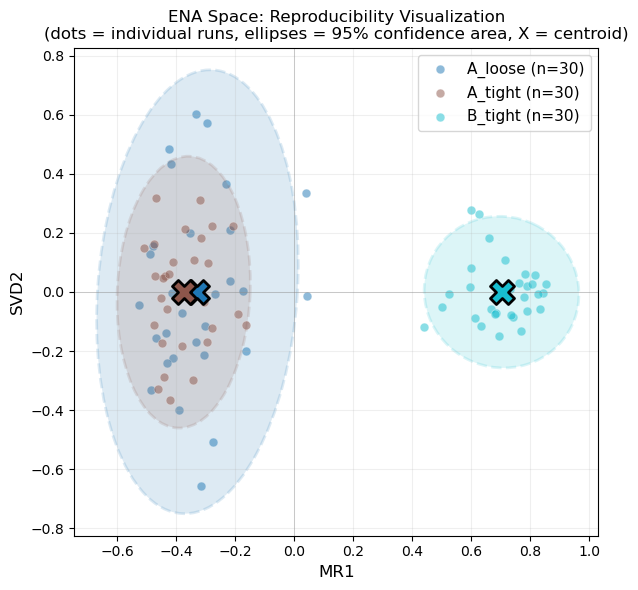

viz/plots.py 영어화 — 그림 생성 OK, 영어 라벨 확인


In [37]:
for mod in list(sys.modules):
    if mod.startswith('pyena'):
        del sys.modules[mod]

from pyena.viz.plots import plot_reproducibility

with open(PROJECT_ROOT / 'tests/data/mr_validation_results.pkl', 'rb') as f:
    mr_ref = pickle.load(f)

fig, ax = plt.subplots(figsize=(8, 6))
plot_reproducibility(mr_ref['pyena_mr_points'], mr_ref['group_labels'], ax=ax,
                     xlabel='MR1', ylabel='SVD2')
plt.tight_layout()
plt.show()

print("viz/plots.py 영어화 — 그림 생성 OK, 영어 라벨 확인")

In [38]:
%%writefile ../src/pyena/api.py
"""scikit-learn-style ENA estimator — the recommended entry point of pyena.

Basic usage
-----------
.. code-block:: python

    from pyena import ENA

    # SVD coordinates
    ena = ENA(codes=['c1', 'c2', 'c3'], window_size=4)
    ena.fit(df)
    coords = ena.transform(df)        # or simply ena.coords_

    # Means-rotation coordinates (for two-group analyses)
    ena = ENA(codes=codes, rotation='means', mr_groups=('A', 'B'))
    ena.fit(df)                       # df must contain a 'group' column
    ena.plot()
    ena.compare(axis='x')
    ena.reproducibility()

Fitted attributes (scikit-learn convention: trailing ``_``)
-----------------------------------------------------------
- ``av_``                : ``(n_units, n_pairs)`` — rENA-exact adjacency vectors.
- ``av_normalized_``     : ``(n_units, n_pairs)`` — sphere-normalized AVs.
- ``av_centered_``       : ``(n_units, n_pairs)`` — centered (training mean).
- ``mean_``              : ``(n_pairs,)`` — column means used for centering.
- ``components_``        : ``(n_components, n_pairs)`` — projection axes;
                          ``coords == centered @ components_.T``.
- ``singular_values_``   : ``(n_components,)`` — only when ``rotation='svd'``.
- ``rotation_matrix_``   : ``(n_pairs, n_pairs)`` — only when ``rotation='means'``.
- ``mr_groups_used_``    : tuple ``(group_a, group_b)`` — only for MR.
- ``coords_``            : ``(n_units, n_components)`` — coordinates of the
                          training data.
- ``unit_ids_``, ``group_ids_``, ``codes_``, ``n_features_in_``.
"""

from __future__ import annotations

import numpy as np
from sklearn.base import BaseEstimator

from pyena.core.adjacency import compute_all_avs
from pyena.core.normalize import sphere_normalize
from pyena.core.projection import means_rotation, svd_project

__all__ = ["ENA"]


class ENA(BaseEstimator):
    """rENA-exact Epistemic Network Analysis estimator (scikit-learn style).

    Wraps the low-level building blocks of pyena (adjacency vector
    construction, sphere normalization, SVD projection, and optional
    means rotation) behind a single ``fit`` / ``transform`` interface that
    follows scikit-learn conventions.

    Parameters
    ----------
    codes : list of str
        Names of the binary code columns in the input frame.
    unit_col : str, default 'unit'
        Column defining ENA units.
    conversation_col : str, default 'conversation'
        Column bounding the moving-stanza window (windows do not cross
        conversation boundaries).
    group_col : str, default 'group'
        Column holding group labels. Used by ``rotation='means'`` and by the
        convenience methods ``plot``, ``compare``, and ``reproducibility``.
    window_size : int, default 4
        Moving-stanza window size.
    window_forward : int, default 0
        Forward lookahead. rENA's default is 0.
    binary : bool, default True
        If True, co-occurrence counts are clipped to 0/1 (rENA default).
    n_components : int, default 2
        Number of components to retain.
    rotation : {'svd', 'means'}, default 'svd'
        Post-projection rotation strategy. ``'svd'`` keeps the top singular
        components (matches rENA's default ``ena.svd``). ``'means'`` rotates
        so that the first axis aligns with the difference of two group means
        (matches rENA's ``ena.rotate.by.mean``) and requires ``mr_groups``.
    mr_groups : tuple of (object, object), optional
        Required when ``rotation='means'``. Defines the rotation axis:
        ``mean(group_a) - mean(group_b)`` points in the positive direction of
        the first axis.

    See Also
    --------
    pyena.core.adjacency.compute_all_avs : Adjacency-vector construction.
    pyena.core.projection.svd_project    : SVD projection.
    pyena.core.projection.means_rotation : rENA-exact means rotation.
    """

    def __init__(
        self,
        codes,
        unit_col='unit',
        conversation_col='conversation',
        group_col='group',
        window_size=4,
        window_forward=0,
        binary=True,
        n_components=2,
        rotation='svd',
        mr_groups=None,
    ):
        self.codes = codes
        self.unit_col = unit_col
        self.conversation_col = conversation_col
        self.group_col = group_col
        self.window_size = window_size
        self.window_forward = window_forward
        self.binary = binary
        self.n_components = n_components
        self.rotation = rotation
        self.mr_groups = mr_groups

    def _prep_df(self, X):
        """Rename ``group_col`` to ``'group'`` for downstream compatibility."""
        if self.group_col != 'group' and self.group_col in X.columns:
            return X.rename(columns={self.group_col: 'group'})
        return X

    def fit(self, X, y=None):
        """Fit the ENA model: adjacency → normalize → project → (optional) rotate.

        Parameters
        ----------
        X : pd.DataFrame
            Long-format utterance frame.
        y : ignored
            Present for scikit-learn API compatibility. Group labels are read
            from the column named ``group_col``.

        Returns
        -------
        self : ENA
        """
        if self.rotation not in ('svd', 'means'):
            raise ValueError(
                f"rotation must be 'svd' or 'means'. Got: {self.rotation!r}"
            )
        if self.rotation == 'means' and self.mr_groups is None:
            raise ValueError(
                "rotation='means' requires mr_groups=(group_a, group_b)."
            )

        df_use = self._prep_df(X)

        av, unit_ids, group_ids = compute_all_avs(
            df_use, self.codes,
            unit_col=self.unit_col,
            conversation_col=self.conversation_col,
            window_size=self.window_size,
            window_forward=self.window_forward,
            binary=self.binary,
        )

        av_n = sphere_normalize(av)
        proj = svd_project(av_n, n_components=self.n_components)

        if self.rotation == 'svd':
            self.coords_ = proj.coords
            self.components_ = proj.components
            self.singular_values_ = proj.singular_values
            self.rotation_matrix_ = None
            self.mr_groups_used_ = None
        else:  # 'means'
            if not group_ids:
                raise ValueError(
                    f"rotation='means' requires a {self.group_col!r} column "
                    f"in X."
                )
            group_arr = np.array(group_ids)
            ga, gb = self.mr_groups
            mr = means_rotation(proj.centered, group_arr, ga, gb)
            # Keep only the first n_components axes.
            self.coords_ = mr.points[:, :self.n_components]
            # scikit-learn convention: coords = centered @ components_.T.
            # In MR: coords = centered @ rotation[:, :n], so
            # components_ = rotation[:, :n].T → shape (n_components, n_features).
            self.components_ = mr.rotation[:, :self.n_components].T
            self.singular_values_ = None
            self.rotation_matrix_ = mr.rotation
            self.mr_groups_used_ = mr.groups_used

        # Shared fitted attributes
        self.av_ = av
        self.av_normalized_ = av_n
        self.av_centered_ = proj.centered
        self.mean_ = proj.mean
        self.unit_ids_ = unit_ids
        self.group_ids_ = group_ids
        self.codes_ = list(self.codes)
        self.n_features_in_ = av.shape[1]

        return self

    def transform(self, X):
        """Project new data into the fitted ENA space.

        Pipeline: AV construction → sphere normalization → centering with the
        training mean → projection through ``components_``.

        Parameters
        ----------
        X : pd.DataFrame
            Long-format utterance frame.

        Returns
        -------
        np.ndarray of shape (n_units, n_components)
        """
        if not hasattr(self, 'mean_'):
            raise RuntimeError("Call fit() before transform().")

        df_use = self._prep_df(X)
        av, _, _ = compute_all_avs(
            df_use, self.codes,
            unit_col=self.unit_col,
            conversation_col=self.conversation_col,
            window_size=self.window_size,
            window_forward=self.window_forward,
            binary=self.binary,
        )
        av_n = sphere_normalize(av)
        centered = av_n - self.mean_
        return centered @ self.components_.T

    def fit_transform(self, X, y=None):
        """Fit the model and return the training-data coordinates."""
        return self.fit(X, y).coords_

    # ===== Convenience methods =====

    def plot(self, ax=None, **kwargs):
        """Visualize the fitted ENA space (requires ``group_ids_``).

        Thin wrapper around :func:`pyena.viz.plots.plot_reproducibility`.
        """
        from pyena.viz.plots import plot_reproducibility
        if not self.group_ids_:
            raise ValueError(
                f"plot() requires a {self.group_col!r} column in X."
            )
        return plot_reproducibility(
            self.coords_, np.array(self.group_ids_), ax=ax, **kwargs
        )

    def compare(self, axis='x', groups=None, n_permutations=10000, random_state=42):
        """Two-group comparison (Welch + Mann-Whitney + permutation).

        Parameters
        ----------
        axis : {'x', 'y'}, default 'x'
            Which axis to test.
        groups : tuple of (object, object), optional
            The two groups to compare. If ``None``, ``mr_groups_used_`` is
            used (available only when ``rotation='means'``).
        n_permutations, random_state
            Passed to :func:`pyena.stats.compare.ena_group_comparison`.

        Returns
        -------
        dict
            Results dictionary as returned by ``ena_group_comparison``.
        """
        from pyena.stats.compare import ena_group_comparison
        if not self.group_ids_:
            raise ValueError(
                f"compare() requires a {self.group_col!r} column in X."
            )
        if groups is None:
            if self.mr_groups_used_ is None:
                raise ValueError(
                    "More than two groups present. Pass groups=(a, b) "
                    "explicitly, or fit with rotation='means' to set "
                    "mr_groups_used_."
                )
            groups = self.mr_groups_used_
        labels = np.array(self.group_ids_)
        mask = np.isin(labels, groups)
        return ena_group_comparison(
            self.coords_[mask], labels[mask],
            axis=axis, n_permutations=n_permutations, random_state=random_state,
        )

    def reproducibility(self):
        """Compute the four reproducibility indicators per group.

        Returns
        -------
        pd.DataFrame
            As returned by :func:`pyena.stats.reproducibility.reproducibility_metrics`.
        """
        from pyena.stats.reproducibility import reproducibility_metrics
        labels = np.array(self.group_ids_) if self.group_ids_ else None
        return reproducibility_metrics(self.coords_, labels)

Overwriting ../src/pyena/api.py


In [39]:
# __init__.py 영어화
init_content = '''"""pyena: a rENA-exact Python implementation of Epistemic Network Analysis."""

from pyena.api import ENA

__all__ = ["ENA"]
__version__ = "0.1.0.dev0"
'''
(PROJECT_ROOT / 'src' / 'pyena' / '__init__.py').write_text(init_content)

# 모듈 캐시 비우고 재import
for mod in list(sys.modules):
    if mod.startswith('pyena'):
        del sys.modules[mod]

from pyena import ENA

# 모든 reference 로드
df = pd.read_csv(PROJECT_ROOT / 'tests/data/toy_data_n90.csv')
codes = ['Data', 'Theory', 'Question', 'Example', 'Critique']
with open(PROJECT_ROOT / 'tests/data/rena_validation_results.pkl', 'rb') as f:
    ref02 = pickle.load(f)
with open(PROJECT_ROOT / 'tests/data/mr_validation_results.pkl', 'rb') as f:
    mr_ref = pickle.load(f)
with open(PROJECT_ROOT / 'tests/data/compare_reference.pkl', 'rb') as f:
    cmp_ref = pickle.load(f)
with open(PROJECT_ROOT / 'tests/data/reproducibility_reference.pkl', 'rb') as f:
    repro_ref = pickle.load(f)

def align_sign(a, b):
    out = a.copy()
    for k in range(a.shape[1]):
        if np.dot(a[:, k], b[:, k]) < 0:
            out[:, k] = -a[:, k]
    return out

# 시나리오 1: SVD
ena_svd = ENA(codes=codes, window_size=4, rotation='svd').fit(df)
diff_av = np.abs(ena_svd.av_ - ref02['pyena_avs']).max()

# 시나리오 2: MR
ena_mr = ENA(codes=codes, window_size=4, rotation='means',
             mr_groups=('A_tight', 'B_tight')).fit(df)
mr_signed = align_sign(ena_mr.coords_, mr_ref['rena_mr_points'])
diff_mr_vs_rena = np.abs(mr_signed - mr_ref['rena_mr_points']).max()

# compare
cmp = ena_mr.compare(axis='x')
diff_cmp = max(abs(cmp[k] - cmp_ref['result_x'][k]) 
               for k in cmp_ref['result_x'] 
               if isinstance(cmp_ref['result_x'][k], (int, float, np.integer, np.floating)))

# reproducibility
repro = ena_mr.reproducibility()
diff_repro = np.abs(repro.astype(float).to_numpy() 
                    - repro_ref['result_grouped'].astype(float).to_numpy())
diff_repro[np.isnan(diff_repro)] = 0
diff_repro_max = diff_repro.max()

print("=" * 60)
print("최종 통합 검증 — 영어화 후 ENA() 전체 워크플로우")
print("=" * 60)
print(f"  AV vs rENA-exact:                max |Δ| = {diff_av:.2e}")
print(f"  MR coords vs rENA MR1/SVD2:      max |Δ| = {diff_mr_vs_rena:.2e}")
print(f"  ena.compare() vs reference:      max |Δ| = {diff_cmp:.2e}")
print(f"  ena.reproducibility() vs ref:    max |Δ| = {diff_repro_max:.2e}")
print()
print("docstring 영어화 확인:")
print(f"  ENA class:")
print(f"    {ENA.__doc__.split(chr(10))[0]}")
print(f"  ENA.fit:")
print(f"    {ENA.fit.__doc__.split(chr(10))[0]}")
print(f"  ENA.compare:")
print(f"    {ENA.compare.__doc__.split(chr(10))[0]}")

최종 통합 검증 — 영어화 후 ENA() 전체 워크플로우
  AV vs rENA-exact:                max |Δ| = 0.00e+00
  MR coords vs rENA MR1/SVD2:      max |Δ| = 3.68e-16
  ena.compare() vs reference:      max |Δ| = 0.00e+00
  ena.reproducibility() vs ref:    max |Δ| = 0.00e+00

docstring 영어화 확인:
  ENA class:
    rENA-exact Epistemic Network Analysis estimator (scikit-learn style).
  ENA.fit:
    Fit the ENA model: adjacency → normalize → project → (optional) rotate.
  ENA.compare:
    Two-group comparison (Welch + Mann-Whitney + permutation).


In [41]:
# pytest 설치 여부 + conftest.py가 인식할 수 있도록 conftest 설정 확인
import subprocess

# pytest 버전 확인
result = subprocess.run(['pytest', '--version'], capture_output=True, text=True)
print("pytest 설치 상태:")
print(f"  stdout: {result.stdout.strip()}")
print(f"  stderr: {result.stderr.strip()}")
print()

# tests/ 디렉토리 구조
print("tests/ 디렉토리:")
result = subprocess.run(['ls', '-la', str(PROJECT_ROOT / 'tests')], 
                        capture_output=True, text=True)
print(result.stdout)

pytest 설치 상태:
  stdout: pytest 9.0.3
  stderr: 

tests/ 디렉토리:
total 12
drwxr-xr-x 3 ubuntu ubuntu 4096 May 22 11:20 .
drwxr-xr-x 6 ubuntu ubuntu 4096 May 22 11:20 ..
drwxr-xr-x 2 ubuntu ubuntu 4096 May 22 14:47 data



In [42]:
conftest_content = '''"""Shared pytest fixtures for the pyena test suite.

All test modules import these via the standard pytest fixture-discovery
mechanism — no explicit imports are needed.
"""

from __future__ import annotations

import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import pytest

# Make `src/pyena` importable when running tests from a fresh checkout.
PROJECT_ROOT = Path(__file__).resolve().parent.parent
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

DATA_DIR = Path(__file__).resolve().parent / "data"


# ===== Path / loader fixtures =====

@pytest.fixture(scope="session")
def data_dir():
    """Absolute path to the bundled test-data directory."""
    return DATA_DIR


@pytest.fixture(scope="session")
def toy_data():
    """The 90-unit toy DataFrame used throughout validation."""
    p = DATA_DIR / "toy_data_n90.csv"
    if not p.exists():
        pytest.fail(f"toy_data_n90.csv missing at {p}")
    return pd.read_csv(p)


@pytest.fixture(scope="session")
def codes():
    """The five code names used by the toy dataset."""
    return ["Data", "Theory", "Question", "Example", "Critique"]


# ===== Reference-pickle fixtures =====

@pytest.fixture(scope="session")
def pyena_reference():
    """pyena_reference_output.pkl — AV, normalized, centered, SVD coords."""
    p = DATA_DIR / "pyena_reference_output.pkl"
    if not p.exists():
        pytest.fail(f"pyena_reference_output.pkl missing at {p}")
    with p.open("rb") as f:
        return pickle.load(f)


@pytest.fixture(scope="session")
def rena_reference():
    """rena_validation_results.pkl — rENA-exact AV + SVD comparison."""
    p = DATA_DIR / "rena_validation_results.pkl"
    if not p.exists():
        pytest.fail(f"rena_validation_results.pkl missing at {p}")
    with p.open("rb") as f:
        return pickle.load(f)


@pytest.fixture(scope="session")
def mr_reference():
    """mr_validation_results.pkl — rENA means-rotation comparison."""
    p = DATA_DIR / "mr_validation_results.pkl"
    if not p.exists():
        pytest.fail(f"mr_validation_results.pkl missing at {p}")
    with p.open("rb") as f:
        return pickle.load(f)


@pytest.fixture(scope="session")
def compare_reference():
    """compare_reference.pkl — ena_group_comparison reference outputs."""
    p = DATA_DIR / "compare_reference.pkl"
    if not p.exists():
        pytest.fail(f"compare_reference.pkl missing at {p}")
    with p.open("rb") as f:
        return pickle.load(f)


@pytest.fixture(scope="session")
def reproducibility_reference():
    """reproducibility_reference.pkl — reproducibility_metrics reference."""
    p = DATA_DIR / "reproducibility_reference.pkl"
    if not p.exists():
        pytest.fail(f"reproducibility_reference.pkl missing at {p}")
    with p.open("rb") as f:
        return pickle.load(f)


# ===== Helpers =====

@pytest.fixture(scope="session")
def align_sign():
    """Return a function that sign-aligns the columns of `a` to those of `b`.

    SVD-based outputs have an arbitrary sign per component; alignment is the
    standard way to compare them without spurious mismatches.
    """
    def _align_sign(a, b):
        out = a.copy()
        for k in range(a.shape[1]):
            if np.dot(a[:, k], b[:, k]) < 0:
                out[:, k] = -a[:, k]
        return out
    return _align_sign
'''

conftest_path = PROJECT_ROOT / 'tests' / 'conftest.py'
conftest_path.write_text(conftest_content)
print(f"작성: {conftest_path}")
print(f"크기: {conftest_path.stat().st_size:,} bytes")

작성: /home/ubuntu/research/2026/research_pyena/tests/conftest.py
크기: 3,382 bytes


In [43]:
compare_test = '''"""Tests for pyena.stats.compare."""

import numpy as np
import pytest
from scipy import stats as scipy_stats

from pyena.stats.compare import ena_group_comparison


# ===== Reference regression =====

class TestCompareReference:
    def test_x_axis_matches_notebook_reference(self, compare_reference):
        pkg = ena_group_comparison(
            compare_reference["input_points"],
            compare_reference["input_labels"],
            axis="x",
            n_permutations=compare_reference["n_permutations"],
            random_state=compare_reference["random_state"],
        )
        ref = compare_reference["result_x"]
        for k, v in ref.items():
            if isinstance(v, (int, float, np.integer, np.floating)):
                assert pkg[k] == pytest.approx(v, abs=0, rel=0), f"mismatch in {k}"
            else:
                assert pkg[k] == v, f"mismatch in {k}"

    def test_y_axis_matches_notebook_reference(self, compare_reference):
        pkg = ena_group_comparison(
            compare_reference["input_points"],
            compare_reference["input_labels"],
            axis="y",
            n_permutations=compare_reference["n_permutations"],
            random_state=compare_reference["random_state"],
        )
        ref = compare_reference["result_y"]
        for k, v in ref.items():
            if isinstance(v, (int, float, np.integer, np.floating)):
                assert pkg[k] == pytest.approx(v, abs=0, rel=0), f"mismatch in {k}"
            else:
                assert pkg[k] == v


# ===== scipy external cross-check =====

class TestScipyCrossCheck:
    """The Welch and Mann-Whitney values must match scipy directly."""

    def test_welch_matches_scipy(self, compare_reference):
        pts = compare_reference["input_points"]
        labels = compare_reference["input_labels"]
        groups = np.unique(labels)
        for axis, axis_idx in [("x", 0), ("y", 1)]:
            g1 = pts[labels == groups[0], axis_idx]
            g2 = pts[labels == groups[1], axis_idx]
            t_scipy, p_scipy = scipy_stats.ttest_ind(g1, g2, equal_var=False)
            pkg = ena_group_comparison(pts, labels, axis=axis, random_state=0,
                                       n_permutations=1)  # perms don't matter here
            assert pkg["welch_t"] == t_scipy
            assert pkg["welch_p"] == p_scipy

    def test_mannwhitney_matches_scipy(self, compare_reference):
        pts = compare_reference["input_points"]
        labels = compare_reference["input_labels"]
        groups = np.unique(labels)
        for axis, axis_idx in [("x", 0), ("y", 1)]:
            g1 = pts[labels == groups[0], axis_idx]
            g2 = pts[labels == groups[1], axis_idx]
            u_scipy, p_scipy = scipy_stats.mannwhitneyu(g1, g2, alternative="two-sided")
            pkg = ena_group_comparison(pts, labels, axis=axis, random_state=0,
                                       n_permutations=1)
            assert pkg["mannwhitney_U"] == u_scipy
            assert pkg["mannwhitney_p"] == p_scipy


# ===== Algorithmic properties =====

class TestProperties:
    def test_raises_on_more_than_two_groups(self):
        pts = np.random.default_rng(0).random((30, 2))
        labels = np.array(["A"] * 10 + ["B"] * 10 + ["C"] * 10)
        with pytest.raises(ValueError, match="Exactly two groups"):
            ena_group_comparison(pts, labels)

    def test_raises_on_single_group(self):
        pts = np.random.default_rng(0).random((10, 2))
        labels = np.array(["A"] * 10)
        with pytest.raises(ValueError, match="Exactly two groups"):
            ena_group_comparison(pts, labels)

    def test_small_sample_emits_warning(self):
        pts = np.array([[1.0, 0], [2.0, 0], [3.0, 0],
                        [10.0, 0], [11.0, 0], [12.0, 0]])
        labels = np.array(["A", "A", "A", "B", "B", "B"])
        with pytest.warns(UserWarning, match="Small sample warning"):
            ena_group_comparison(pts, labels, n_permutations=100, random_state=0)

    def test_permutation_p_value_in_unit_interval(self):
        rng = np.random.default_rng(0)
        pts = rng.random((40, 2))
        labels = np.array(["A"] * 20 + ["B"] * 20)
        result = ena_group_comparison(pts, labels, n_permutations=500, random_state=0)
        assert 0.0 <= result["permutation_p"] <= 1.0

    def test_permutation_p_reproducible_with_seed(self):
        rng = np.random.default_rng(0)
        pts = rng.random((40, 2))
        labels = np.array(["A"] * 20 + ["B"] * 20)
        r1 = ena_group_comparison(pts, labels, n_permutations=500, random_state=42)
        r2 = ena_group_comparison(pts, labels, n_permutations=500, random_state=42)
        assert r1["permutation_p"] == r2["permutation_p"]

    def test_identical_distributions_give_large_p_values(self):
        rng = np.random.default_rng(0)
        pts = rng.standard_normal((100, 2))
        labels = np.array(["A"] * 50 + ["B"] * 50)
        result = ena_group_comparison(pts, labels, n_permutations=500, random_state=0)
        # Under H0, all three p-values should be reasonably large
        assert result["welch_p"] > 0.1
        assert result["mannwhitney_p"] > 0.1
        assert result["permutation_p"] > 0.1

    def test_cohens_d_sign_matches_observed_diff_sign(self):
        rng = np.random.default_rng(0)
        pts = rng.random((20, 2))
        labels = np.array(["A"] * 10 + ["B"] * 10)
        result = ena_group_comparison(pts, labels, n_permutations=100, random_state=0)
        assert np.sign(result["cohens_d"]) == np.sign(result["observed_diff"])

    def test_axis_x_and_y_use_different_columns(self):
        pts = np.column_stack([
            np.concatenate([np.zeros(10), np.ones(10)]),       # huge x-axis diff
            np.random.default_rng(0).standard_normal(20),      # noise on y
        ])
        labels = np.array(["A"] * 10 + ["B"] * 10)
        res_x = ena_group_comparison(pts, labels, axis="x",
                                     n_permutations=100, random_state=0)
        res_y = ena_group_comparison(pts, labels, axis="y",
                                     n_permutations=100, random_state=0)
        assert res_x["welch_p"] < res_y["welch_p"]
'''

path = PROJECT_ROOT / 'tests' / 'test_compare.py'
path.write_text(compare_test)

import subprocess
result = subprocess.run(
    ['pytest', str(path), '-v'],
    capture_output=True, text=True, cwd=str(PROJECT_ROOT),
)
print(result.stdout[-3500:])
if result.stderr:
    print("=== STDERR ===")
    print(result.stderr[-500:])
print(f"return code: {result.returncode}")

================================================= test session starts ==================================================
platform linux -- Python 3.13.2, pytest-9.0.3, pluggy-1.6.0 -- /home/ubuntu/anaconda3/envs/test/bin/python3.13
cachedir: .pytest_cache
Matplotlib: 3.10.0
Freetype: 2.14.3
rootdir: /home/ubuntu/research/2026/research_pyena
plugins: anyio-4.7.0, mpl-0.19.0, langsmith-0.5.1
collecting ... collected 12 items

tests/test_compare.py::TestCompareReference::test_x_axis_matches_notebook_reference PASSED                       [  8%]
tests/test_compare.py::TestCompareReference::test_y_axis_matches_notebook_reference PASSED                       [ 16%]
tests/test_compare.py::TestScipyCrossCheck::test_welch_matches_scipy PASSED                                      [ 25%]
tests/test_compare.py::TestScipyCrossCheck::test_mannwhitney_matches_scipy PASSED                                [ 33%]
tests/test_compare.py::TestProperties::test_raises_on_more_than_two_groups PASSED           

In [44]:
reproducibility_test = '''"""Tests for pyena.stats.reproducibility."""

import numpy as np
import pytest
from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist
from scipy.stats import chi2

from pyena.stats.reproducibility import reproducibility_metrics


# ===== Reference regression =====

class TestReproducibilityReference:
    def test_grouped_matches_notebook_reference(self, reproducibility_reference):
        pkg = reproducibility_metrics(
            reproducibility_reference["input_points"],
            reproducibility_reference["input_labels"],
        )
        ref = reproducibility_reference["result_grouped"]
        assert list(pkg.index) == list(ref.index)
        assert list(pkg.columns) == list(ref.columns)
        pkg_num = pkg.astype(float).to_numpy()
        ref_num = ref.astype(float).to_numpy()
        diff = np.abs(pkg_num - ref_num)
        diff[np.isnan(pkg_num) & np.isnan(ref_num)] = 0
        assert diff.max() == 0.0

    def test_all_matches_notebook_reference(self, reproducibility_reference):
        pkg = reproducibility_metrics(reproducibility_reference["input_points"], None)
        ref = reproducibility_reference["result_all"]
        assert list(pkg.index) == ["all"]
        diff = np.abs(pkg.astype(float).to_numpy() - ref.astype(float).to_numpy())
        assert diff.max() == 0.0


# ===== Individual metric cross-checks against standard implementations =====

class TestMetricFormulas:
    """Each metric must match a direct implementation of its definition."""

    @pytest.fixture
    def sample(self, reproducibility_reference):
        labels = reproducibility_reference["input_labels"]
        pts = reproducibility_reference["input_points"][labels == "A_tight"]
        return pts

    def test_centroid_dispersion_formula(self, sample):
        df = reproducibility_metrics(sample, None)
        centroid = sample.mean(axis=0)
        d = np.linalg.norm(sample - centroid, axis=1)
        assert df.loc["all", "centroid_dispersion_mean"] == d.mean()
        assert df.loc["all", "centroid_dispersion_std"] == d.std()

    def test_pairwise_distance_formula(self, sample):
        df = reproducibility_metrics(sample, None)
        pw = pdist(sample)
        assert df.loc["all", "pairwise_distance_mean"] == pw.mean()
        assert df.loc["all", "pairwise_distance_max"] == pw.max()

    def test_ellipse_area_formula(self, sample):
        df = reproducibility_metrics(sample, None)
        cov = np.cov(sample.T)
        eig = np.linalg.eigvalsh(cov)
        expected = np.pi * chi2.ppf(0.95, df=2) * np.sqrt(eig[0] * eig[1])
        assert df.loc["all", "ellipse_95_area"] == expected

    def test_convex_hull_formula(self, sample):
        df = reproducibility_metrics(sample, None)
        hull = ConvexHull(sample)
        assert df.loc["all", "convex_hull_area"] == hull.volume


# ===== Properties / edge cases =====

class TestProperties:
    def test_zero_dispersion_for_identical_points(self):
        pts = np.tile([1.0, 2.0], (10, 1))
        df = reproducibility_metrics(pts, None)
        assert df.loc["all", "centroid_dispersion_mean"] == 0.0
        assert df.loc["all", "pairwise_distance_mean"] == 0.0
        assert df.loc["all", "pairwise_distance_max"] == 0.0
        # cov is zero → ellipse area is 0
        assert df.loc["all", "ellipse_95_area"] == 0.0

    def test_dispersion_scales_with_spread(self):
        rng = np.random.default_rng(0)
        base = rng.standard_normal((30, 2))
        tight = reproducibility_metrics(base, None).loc["all", "centroid_dispersion_mean"]
        loose = reproducibility_metrics(5 * base, None).loc["all", "centroid_dispersion_mean"]
        # 5x spread should give exactly 5x dispersion
        assert loose == pytest.approx(5 * tight, rel=1e-12)

    def test_single_point_returns_nan_for_size_dependent_metrics(self):
        pts = np.array([[1.0, 2.0]])
        df = reproducibility_metrics(pts, None)
        assert df.loc["all", "n"] == 1
        assert df.loc["all", "centroid_dispersion_mean"] == 0.0
        assert np.isnan(df.loc["all", "pairwise_distance_mean"])
        assert np.isnan(df.loc["all", "ellipse_95_area"])
        assert np.isnan(df.loc["all", "convex_hull_area"])

    def test_two_points_have_pairwise_but_no_ellipse(self):
        pts = np.array([[0.0, 0.0], [3.0, 4.0]])
        df = reproducibility_metrics(pts, None)
        assert df.loc["all", "pairwise_distance_mean"] == 5.0
        assert df.loc["all", "pairwise_distance_max"] == 5.0
        assert np.isnan(df.loc["all", "ellipse_95_area"])
        assert np.isnan(df.loc["all", "convex_hull_area"])

    def test_grouped_returns_one_row_per_group(self, reproducibility_reference):
        df = reproducibility_metrics(
            reproducibility_reference["input_points"],
            reproducibility_reference["input_labels"],
        )
        assert set(df.index) == {"A_loose", "A_tight", "B_tight"}
        assert len(df) == 3

    def test_columns_are_consistent(self, reproducibility_reference):
        df_g = reproducibility_metrics(
            reproducibility_reference["input_points"],
            reproducibility_reference["input_labels"],
        )
        df_a = reproducibility_metrics(reproducibility_reference["input_points"], None)
        assert list(df_g.columns) == list(df_a.columns)

    def test_toy_data_loose_is_more_dispersed_than_tight(self, reproducibility_reference):
        """Sanity check: A_loose has 0.20 jitter, A_tight has 0.03 → looser."""
        df = reproducibility_metrics(
            reproducibility_reference["input_points"],
            reproducibility_reference["input_labels"],
        )
        for metric in ["centroid_dispersion_mean", "pairwise_distance_mean",
                       "ellipse_95_area", "convex_hull_area"]:
            assert df.loc["A_loose", metric] > df.loc["A_tight", metric], (
                f"A_loose should be more dispersed than A_tight in {metric}"
            )
'''

path = PROJECT_ROOT / 'tests' / 'test_reproducibility.py'
path.write_text(reproducibility_test)

import subprocess
result = subprocess.run(
    ['pytest', str(path), '-v'],
    capture_output=True, text=True, cwd=str(PROJECT_ROOT),
)
print(result.stdout[-3500:])
if result.stderr:
    print("=== STDERR ===")
    print(result.stderr[-500:])
print(f"return code: {result.returncode}")

================================================= test session starts ==================================================
platform linux -- Python 3.13.2, pytest-9.0.3, pluggy-1.6.0 -- /home/ubuntu/anaconda3/envs/test/bin/python3.13
cachedir: .pytest_cache
Matplotlib: 3.10.0
Freetype: 2.14.3
rootdir: /home/ubuntu/research/2026/research_pyena
plugins: anyio-4.7.0, mpl-0.19.0, langsmith-0.5.1
collecting ... collected 13 items

tests/test_reproducibility.py::TestReproducibilityReference::test_grouped_matches_notebook_reference PASSED      [  7%]
tests/test_reproducibility.py::TestReproducibilityReference::test_all_matches_notebook_reference PASSED          [ 15%]
tests/test_reproducibility.py::TestMetricFormulas::test_centroid_dispersion_formula PASSED                       [ 23%]
tests/test_reproducibility.py::TestMetricFormulas::test_pairwise_distance_formula PASSED                         [ 30%]
tests/test_reproducibility.py::TestMetricFormulas::test_ellipse_area_formula PASSED         

In [45]:
viz_test = '''"""Tests for pyena.viz.plots."""

import matplotlib
matplotlib.use("Agg")  # headless backend for CI
import matplotlib.pyplot as plt
import numpy as np
import pytest
from matplotlib.patches import Ellipse
from scipy.stats import chi2

from pyena.viz.plots import plot_reproducibility


def _extract_structure(ax):
    """Pull scatter coords, centroid coords, and ellipse params from an Axes."""
    scatters, centroids, ellipses = [], [], []
    for coll in ax.collections:
        offsets = coll.get_offsets()
        if len(offsets) == 1:
            centroids.append(np.array(offsets[0]))
        else:
            scatters.append(np.array(offsets))
    for patch in ax.patches:
        if isinstance(patch, Ellipse):
            ellipses.append({
                "center": np.array(patch.get_center()),
                "width": patch.get_width(),
                "height": patch.get_height(),
                "angle": patch.angle,
            })
    return scatters, centroids, ellipses


# ===== Figure structure =====

class TestStructure:
    def test_returns_axes(self, mr_reference):
        fig, ax = plt.subplots()
        out = plot_reproducibility(
            mr_reference["pyena_mr_points"], mr_reference["group_labels"], ax=ax,
        )
        assert out is ax
        plt.close(fig)

    def test_one_scatter_per_group(self, mr_reference):
        fig, ax = plt.subplots()
        plot_reproducibility(
            mr_reference["pyena_mr_points"], mr_reference["group_labels"], ax=ax,
        )
        scatters, centroids, ellipses = _extract_structure(ax)
        n_groups = len(np.unique(mr_reference["group_labels"]))
        assert len(scatters) == n_groups
        assert len(centroids) == n_groups
        assert len(ellipses) == n_groups
        plt.close(fig)

    def test_scatter_count_per_group_correct(self, mr_reference):
        fig, ax = plt.subplots()
        plot_reproducibility(
            mr_reference["pyena_mr_points"], mr_reference["group_labels"], ax=ax,
        )
        scatters, _, _ = _extract_structure(ax)
        labels = mr_reference["group_labels"]
        for g, sc in zip(np.unique(labels), scatters):
            expected_n = (labels == g).sum()
            assert len(sc) == expected_n
        plt.close(fig)

    def test_ellipse_not_drawn_when_show_ellipse_false(self, mr_reference):
        fig, ax = plt.subplots()
        plot_reproducibility(
            mr_reference["pyena_mr_points"], mr_reference["group_labels"],
            ax=ax, show_ellipse=False,
        )
        _, _, ellipses = _extract_structure(ax)
        assert len(ellipses) == 0
        plt.close(fig)

    def test_creates_new_figure_when_ax_is_none(self, mr_reference):
        ax = plot_reproducibility(
            mr_reference["pyena_mr_points"], mr_reference["group_labels"],
        )
        assert ax is not None
        plt.close(ax.figure)


# ===== Ellipse math =====

class TestEllipseMath:
    def test_ellipse_center_equals_group_centroid(self, mr_reference):
        fig, ax = plt.subplots()
        plot_reproducibility(
            mr_reference["pyena_mr_points"], mr_reference["group_labels"], ax=ax,
        )
        _, centroids, ellipses = _extract_structure(ax)
        for c, el in zip(centroids, ellipses):
            np.testing.assert_array_equal(el["center"], c)
        plt.close(fig)

    def test_ellipse_dimensions_match_formula(self, mr_reference):
        fig, ax = plt.subplots()
        plot_reproducibility(
            mr_reference["pyena_mr_points"], mr_reference["group_labels"], ax=ax,
        )
        _, _, ellipses = _extract_structure(ax)
        chi2_val = chi2.ppf(0.95, df=2)

        labels = mr_reference["group_labels"]
        for g, el in zip(np.unique(labels), ellipses):
            pts = mr_reference["pyena_mr_points"][labels == g]
            cov = np.cov(pts.T)
            eigvals, eigvecs = np.linalg.eigh(cov)
            order = eigvals.argsort()[::-1]
            eigvals = eigvals[order]
            eigvecs = eigvecs[:, order]

            expected_width = 2 * np.sqrt(chi2_val * eigvals[0])
            expected_height = 2 * np.sqrt(chi2_val * eigvals[1])
            expected_angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

            assert el["width"] == pytest.approx(expected_width, rel=1e-12)
            assert el["height"] == pytest.approx(expected_height, rel=1e-12)
            assert el["angle"] == pytest.approx(expected_angle, rel=1e-12)
        plt.close(fig)

    def test_ellipse_skipped_for_groups_with_fewer_than_3_points(self):
        pts = np.array([[0.0, 0.0], [1.0, 1.0]])
        labels = np.array(["A", "A"])
        fig, ax = plt.subplots()
        plot_reproducibility(pts, labels, ax=ax)
        _, _, ellipses = _extract_structure(ax)
        assert len(ellipses) == 0
        plt.close(fig)


# ===== Labels and aesthetics =====

class TestLabels:
    def test_default_axis_labels(self, mr_reference):
        fig, ax = plt.subplots()
        plot_reproducibility(
            mr_reference["pyena_mr_points"], mr_reference["group_labels"], ax=ax,
        )
        assert ax.get_xlabel() == "PC1"
        assert ax.get_ylabel() == "PC2"
        plt.close(fig)

    def test_custom_axis_labels(self, mr_reference):
        fig, ax = plt.subplots()
        plot_reproducibility(
            mr_reference["pyena_mr_points"], mr_reference["group_labels"], ax=ax,
            xlabel="MR1", ylabel="SVD2",
        )
        assert ax.get_xlabel() == "MR1"
        assert ax.get_ylabel() == "SVD2"
        plt.close(fig)

    def test_legend_has_one_entry_per_group(self, mr_reference):
        fig, ax = plt.subplots()
        plot_reproducibility(
            mr_reference["pyena_mr_points"], mr_reference["group_labels"], ax=ax,
        )
        legend_texts = [t.get_text() for t in ax.get_legend().get_texts()]
        assert len(legend_texts) == len(np.unique(mr_reference["group_labels"]))
        # Each label should include the group name and "n=" count
        for t in legend_texts:
            assert "n=" in t
        plt.close(fig)
'''

path = PROJECT_ROOT / 'tests' / 'test_viz.py'
path.write_text(viz_test)

import subprocess
result = subprocess.run(
    ['pytest', str(path), '-v'],
    capture_output=True, text=True, cwd=str(PROJECT_ROOT),
)
print(result.stdout[-3500:])
if result.stderr:
    print("=== STDERR ===")
    print(result.stderr[-500:])
print(f"return code: {result.returncode}")

================================================= test session starts ==================================================
platform linux -- Python 3.13.2, pytest-9.0.3, pluggy-1.6.0 -- /home/ubuntu/anaconda3/envs/test/bin/python3.13
cachedir: .pytest_cache
Matplotlib: 3.10.0
Freetype: 2.14.3
rootdir: /home/ubuntu/research/2026/research_pyena
plugins: anyio-4.7.0, mpl-0.19.0, langsmith-0.5.1
collecting ... collected 11 items

tests/test_viz.py::TestStructure::test_returns_axes PASSED                                                       [  9%]
tests/test_viz.py::TestStructure::test_one_scatter_per_group PASSED                                              [ 18%]
tests/test_viz.py::TestStructure::test_scatter_count_per_group_correct PASSED                                    [ 27%]
tests/test_viz.py::TestStructure::test_ellipse_not_drawn_when_show_ellipse_false PASSED                          [ 36%]
tests/test_viz.py::TestStructure::test_creates_new_figure_when_ax_is_none PASSED            

In [46]:
api_test = '''"""Tests for the ENA estimator (pyena.api)."""

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytest

from pyena import ENA


# ===== End-to-end regression =====

class TestSvdScenario:
    """ENA(rotation='svd') must reproduce every validated reference."""

    @pytest.fixture(scope="class")
    def ena(self, toy_data, codes):
        return ENA(codes=codes, window_size=4, rotation="svd").fit(toy_data)

    def test_av_matches_rena_exact(self, ena, rena_reference):
        diff = np.abs(ena.av_ - rena_reference["pyena_avs"]).max()
        assert diff == 0.0

    def test_unit_ids_match_reference(self, ena, rena_reference):
        assert list(ena.unit_ids_) == list(rena_reference["unit_ids"])

    def test_fitted_attributes_present(self, ena):
        for attr in ["av_", "av_normalized_", "av_centered_", "mean_",
                     "components_", "singular_values_", "coords_",
                     "unit_ids_", "group_ids_", "codes_", "n_features_in_"]:
            assert hasattr(ena, attr), f"missing fitted attribute: {attr}"
        assert ena.rotation_matrix_ is None
        assert ena.mr_groups_used_ is None

    def test_shapes_consistent(self, ena):
        n_units = len(ena.unit_ids_)
        n_pairs = ena.n_features_in_
        assert ena.av_.shape == (n_units, n_pairs)
        assert ena.av_normalized_.shape == (n_units, n_pairs)
        assert ena.av_centered_.shape == (n_units, n_pairs)
        assert ena.mean_.shape == (n_pairs,)
        assert ena.coords_.shape == (n_units, 2)
        assert ena.components_.shape == (2, n_pairs)
        assert ena.singular_values_.shape == (2,)


class TestMeansScenario:
    """ENA(rotation='means') must reproduce the rENA MR validation."""

    @pytest.fixture(scope="class")
    def ena(self, toy_data, codes):
        return ENA(
            codes=codes, window_size=4,
            rotation="means", mr_groups=("A_tight", "B_tight"),
        ).fit(toy_data)

    def test_mr_coords_match_rena(self, ena, mr_reference, align_sign):
        coords_aligned = align_sign(ena.coords_, mr_reference["rena_mr_points"])
        diff = np.abs(coords_aligned - mr_reference["rena_mr_points"]).max()
        assert diff < 1e-10

    def test_mr_specific_attributes(self, ena):
        assert ena.singular_values_ is None
        assert ena.rotation_matrix_ is not None
        assert ena.rotation_matrix_.shape == (ena.n_features_in_, ena.n_features_in_)
        assert ena.mr_groups_used_ == ("A_tight", "B_tight")


# ===== sklearn-style API contract =====

class TestSklearnApi:
    def test_fit_returns_self(self, toy_data, codes):
        ena = ENA(codes=codes, window_size=4)
        assert ena.fit(toy_data) is ena

    def test_transform_requires_fit(self, toy_data, codes):
        ena = ENA(codes=codes, window_size=4)
        with pytest.raises(RuntimeError, match="fit"):
            ena.transform(toy_data)

    def test_transform_on_training_data_matches_coords(self, toy_data, codes):
        ena = ENA(codes=codes, window_size=4).fit(toy_data)
        coords_via_transform = ena.transform(toy_data)
        diff = np.abs(coords_via_transform - ena.coords_).max()
        assert diff < 1e-10

    def test_fit_transform_equals_fit_then_coords(self, toy_data, codes):
        ena1 = ENA(codes=codes, window_size=4).fit(toy_data)
        ena2 = ENA(codes=codes, window_size=4)
        coords2 = ena2.fit_transform(toy_data)
        np.testing.assert_array_equal(coords2, ena1.coords_)

    def test_get_params_round_trip(self, codes):
        ena = ENA(codes=codes, window_size=7, n_components=3,
                  rotation="means", mr_groups=("A", "B"))
        params = ena.get_params()
        assert params["window_size"] == 7
        assert params["n_components"] == 3
        assert params["rotation"] == "means"
        assert params["mr_groups"] == ("A", "B")

    def test_set_params(self, codes):
        ena = ENA(codes=codes, window_size=4)
        ena.set_params(window_size=8, rotation="means", mr_groups=("X", "Y"))
        assert ena.window_size == 8
        assert ena.rotation == "means"


# ===== Parameter validation =====

class TestParameterValidation:
    def test_invalid_rotation_raises(self, toy_data, codes):
        ena = ENA(codes=codes, rotation="invalid")
        with pytest.raises(ValueError, match="rotation must be"):
            ena.fit(toy_data)

    def test_means_without_mr_groups_raises(self, toy_data, codes):
        ena = ENA(codes=codes, rotation="means", mr_groups=None)
        with pytest.raises(ValueError, match="mr_groups"):
            ena.fit(toy_data)

    def test_means_without_group_column_raises(self, toy_data, codes):
        df_no_group = toy_data.drop(columns=["group"])
        ena = ENA(codes=codes, rotation="means", mr_groups=("A_tight", "B_tight"))
        with pytest.raises(ValueError, match="group"):
            ena.fit(df_no_group)


# ===== Convenience methods =====

class TestConvenienceMethods:
    @pytest.fixture(scope="class")
    def ena_mr(self, toy_data, codes):
        return ENA(
            codes=codes, window_size=4,
            rotation="means", mr_groups=("A_tight", "B_tight"),
        ).fit(toy_data)

    def test_compare_uses_mr_groups_by_default(self, ena_mr, compare_reference):
        result = ena_mr.compare(axis="x", random_state=42, n_permutations=10000)
        ref = compare_reference["result_x"]
        for k, v in ref.items():
            if isinstance(v, (int, float, np.integer, np.floating)):
                assert result[k] == v, f"mismatch in {k}"

    def test_compare_with_explicit_groups(self, ena_mr):
        result = ena_mr.compare(
            axis="x", groups=("A_tight", "A_loose"),
            n_permutations=100, random_state=0,
        )
        assert result["n1"] == 30
        assert result["n2"] == 30

    def test_compare_raises_when_three_groups_and_no_mr(self, toy_data, codes):
        ena = ENA(codes=codes, rotation="svd").fit(toy_data)
        with pytest.raises(ValueError, match="More than two groups"):
            ena.compare(axis="x")

    def test_reproducibility_returns_one_row_per_group(self, ena_mr):
        df = ena_mr.reproducibility()
        assert set(df.index) == {"A_tight", "A_loose", "B_tight"}

    def test_plot_returns_axes(self, ena_mr):
        ax = ena_mr.plot()
        assert ax is not None
        plt.close(ax.figure)


# ===== Custom column names =====

class TestColumnRenaming:
    def test_custom_group_col_works(self, toy_data, codes):
        df_renamed = toy_data.rename(columns={"group": "condition"})
        ena = ENA(
            codes=codes, group_col="condition",
            rotation="means", mr_groups=("A_tight", "B_tight"),
        ).fit(df_renamed)
        assert ena.mr_groups_used_ == ("A_tight", "B_tight")
        assert set(ena.group_ids_) == {"A_tight", "A_loose", "B_tight"}
'''

path = PROJECT_ROOT / 'tests' / 'test_api.py'
path.write_text(api_test)

import subprocess
result = subprocess.run(
    ['pytest', str(path), '-v'],
    capture_output=True, text=True, cwd=str(PROJECT_ROOT),
)
print(result.stdout[-4500:])
if result.stderr:
    print("=== STDERR ===")
    print(result.stderr[-500:])
print(f"return code: {result.returncode}")

================================================= test session starts ==================================================
platform linux -- Python 3.13.2, pytest-9.0.3, pluggy-1.6.0 -- /home/ubuntu/anaconda3/envs/test/bin/python3.13
cachedir: .pytest_cache
Matplotlib: 3.10.0
Freetype: 2.14.3
rootdir: /home/ubuntu/research/2026/research_pyena
plugins: anyio-4.7.0, mpl-0.19.0, langsmith-0.5.1
collecting ... collected 21 items

tests/test_api.py::TestSvdScenario::test_av_matches_rena_exact PASSED                                            [  4%]
tests/test_api.py::TestSvdScenario::test_unit_ids_match_reference PASSED                                         [  9%]
tests/test_api.py::TestSvdScenario::test_fitted_attributes_present PASSED                                        [ 14%]
tests/test_api.py::TestSvdScenario::test_shapes_consistent PASSED                                                [ 19%]
tests/test_api.py::TestMeansScenario::test_mr_coords_match_rena PASSED                      

In [47]:
import subprocess
result = subprocess.run(
    ['pytest', 'tests/', '-v', '--tb=short'],
    capture_output=True, text=True, cwd=str(PROJECT_ROOT),
)
print(result.stdout[-4500:])
if result.stderr:
    print("=== STDERR ===")
    print(result.stderr[-500:])
print(f"return code: {result.returncode}")

3%]
tests/test_reproducibility.py::TestMetricFormulas::test_centroid_dispersion_formula PASSED                       [ 74%]
tests/test_reproducibility.py::TestMetricFormulas::test_pairwise_distance_formula PASSED                         [ 75%]
tests/test_reproducibility.py::TestMetricFormulas::test_ellipse_area_formula PASSED                              [ 76%]
tests/test_reproducibility.py::TestMetricFormulas::test_convex_hull_formula PASSED                               [ 77%]
tests/test_reproducibility.py::TestProperties::test_zero_dispersion_for_identical_points PASSED                  [ 78%]
tests/test_reproducibility.py::TestProperties::test_dispersion_scales_with_spread PASSED                         [ 79%]
tests/test_reproducibility.py::TestProperties::test_single_point_returns_nan_for_size_dependent_metrics PASSED   [ 80%]
tests/test_reproducibility.py::TestProperties::test_two_points_have_pairwise_but_no_ellipse PASSED               [ 81%]
tests/test_reproducibility.py::TestP

In [48]:
pyproject_content = '''[build-system]
requires = ["hatchling>=1.21", "hatch-vcs>=0.4"]
build-backend = "hatchling.build"

[project]
name = "pyena"
dynamic = ["version"]
description = "Python implementation of rENA-exact Epistemic Network Analysis"
readme = "README.md"
requires-python = ">=3.10"
license = "BSD-3-Clause"
license-files = ["LICENSE"]
authors = [
    { name = "JongHwi Song", email = "zhegllyang@gmail.com" },
]
maintainers = [
    { name = "JongHwi Song", email = "zhegllyang@gmail.com" },
]
keywords = [
    "epistemic-network-analysis",
    "ena",
    "rena",
    "discourse-analysis",
    "text-mining",
    "reproducibility",
    "llm-analysis",
]
classifiers = [
    "Development Status :: 4 - Beta",
    "Intended Audience :: Science/Research",
    "License :: OSI Approved :: BSD License",
    "Operating System :: OS Independent",
    "Programming Language :: Python :: 3",
    "Programming Language :: Python :: 3.10",
    "Programming Language :: Python :: 3.11",
    "Programming Language :: Python :: 3.12",
    "Programming Language :: Python :: 3.13",
    "Topic :: Scientific/Engineering",
    "Topic :: Scientific/Engineering :: Information Analysis",
    "Topic :: Scientific/Engineering :: Visualization",
]
dependencies = [
    "numpy>=1.24",
    "pandas>=2.0",
    "scipy>=1.10",
    "scikit-learn>=1.3",
    "matplotlib>=3.7",
]

[project.optional-dependencies]
dev = [
    "pytest>=7.4",
    "pytest-cov>=4.1",
    "ruff>=0.5",
    "ipykernel",
]
validate = [
    "rpy2>=3.5",
]
docs = [
    "mkdocs>=1.5",
    "mkdocs-material>=9.5",
    "mkdocstrings[python]>=0.24",
]

[project.urls]
Homepage = "https://github.com/zhegllyang/pyena"
Repository = "https://github.com/zhegllyang/pyena"
Issues = "https://github.com/zhegllyang/pyena/issues"
Changelog = "https://github.com/zhegllyang/pyena/blob/main/CHANGELOG.md"

# ---------- hatch / versioning ----------
[tool.hatch.version]
source = "vcs"

[tool.hatch.build.hooks.vcs]
version-file = "src/pyena/_version.py"

[tool.hatch.build.targets.wheel]
packages = ["src/pyena"]

[tool.hatch.build.targets.sdist]
include = [
    "src/pyena",
    "tests",
    "README.md",
    "LICENSE",
    "CITATION.cff",
    "CHANGELOG.md",
    "pyproject.toml",
]

# ---------- pytest ----------
[tool.pytest.ini_options]
testpaths = ["tests"]
addopts = "-ra --strict-markers"
markers = [
    "slow: marks tests as slow (deselect with -m \\"not slow\\")",
    "rpy2: requires R and rpy2 (deselect with -m \\"not rpy2\\")",
]

[tool.coverage.run]
source = ["pyena"]
branch = true

# ---------- ruff ----------
[tool.ruff]
line-length = 100
target-version = "py310"

[tool.ruff.lint]
select = ["E", "F", "W", "I", "B", "UP", "N"]
ignore = ["N803", "N806"]  # ML conventions: X, U, S, Vt

[tool.ruff.lint.per-file-ignores]
"tests/*" = ["E501"]
"src/pyena/_version.py" = ["ALL"]
'''

path = PROJECT_ROOT / 'pyproject.toml'
path.write_text(pyproject_content)
print(f"작성: {path}")
print(f"크기: {path.stat().st_size:,} bytes")
print()
print("=== 주요 메타데이터 확인 ===")
print(f"name:        pyena")
print(f"license:     BSD-3-Clause")
print(f"python:      >=3.10")
print(f"author:      JongHwi Song <zhegllyang@gmail.com>")
print(f"version src: hatch-vcs (git tag 기반)")

작성: /home/ubuntu/research/2026/research_pyena/pyproject.toml
크기: 2,815 bytes

=== 주요 메타데이터 확인 ===
name:        pyena
license:     BSD-3-Clause
python:      >=3.10
author:      JongHwi Song <zhegllyang@gmail.com>
version src: hatch-vcs (git tag 기반)


In [49]:
# LICENSE (BSD 3-Clause)
license_content = '''BSD 3-Clause License

Copyright (c) 2026, JongHwi Song
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are met:

1. Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

2. Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

3. Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior written permission.

THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS "AS IS"
AND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE
IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE ARE
DISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT HOLDER OR CONTRIBUTORS BE LIABLE
FOR ANY DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, OR CONSEQUENTIAL
DAMAGES (INCLUDING, BUT NOT LIMITED TO, PROCUREMENT OF SUBSTITUTE GOODS OR
SERVICES; LOSS OF USE, DATA, OR PROFITS; OR BUSINESS INTERRUPTION) HOWEVER
CAUSED AND ON ANY THEORY OF LIABILITY, WHETHER IN CONTRACT, STRICT LIABILITY,
OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE) ARISING IN ANY WAY OUT OF THE USE
OF THIS SOFTWARE, EVEN IF ADVISED OF THE POSSIBILITY OF SUCH DAMAGE.
'''

(PROJECT_ROOT / 'LICENSE').write_text(license_content)


# CITATION.cff (Zenodo가 자동으로 DOI 메타데이터 생성)
citation_content = '''cff-version: 1.2.0
title: "pyena: Python implementation of rENA-exact Epistemic Network Analysis"
message: "If you use this software, please cite it using these metadata."
type: software
authors:
  - family-names: "Song"
    given-names: "JongHwi"
    email: "zhegllyang@gmail.com"
    orcid: "https://orcid.org/0009-0005-6388-2172"
    affiliation: "Institute of AI Convergence Sciences, Yonsei University Mirae Campus"
repository-code: "https://github.com/zhegllyang/pyena"
abstract: >-
  pyena is a Python implementation of rENA-exact Epistemic Network Analysis (ENA),
  numerically validated bit-for-bit against the reference R package rENA 0.3.1.
  It provides adjacency vector construction, sphere normalization, SVD projection
  with means rotation, two-group statistical comparison, reproducibility metrics,
  and visualization through a scikit-learn-style API. All three core stages
  (adjacency, SVD, means rotation) have been verified against rENA at machine
  epsilon on a benchmark toy dataset.
keywords:
  - epistemic network analysis
  - ENA
  - rENA
  - discourse analysis
  - text mining
  - reproducibility
  - LLM dialogue analysis
license: BSD-3-Clause
version: 0.1.0
date-released: "2026-01-01"
'''

(PROJECT_ROOT / 'CITATION.cff').write_text(citation_content)


# CHANGELOG.md (Keep a Changelog 형식)
changelog_content = '''# Changelog

All notable changes to pyena will be documented in this file.

The format is based on [Keep a Changelog](https://keepachangelog.com/en/1.1.0/),
and this project adheres to [Semantic Versioning](https://semver.org/spec/v2.0.0.html).

## [0.1.0] - 2026-01-01

### Added
- rENA-exact adjacency vector construction (`compute_all_avs`, `vector_to_ut`,
  `ref_window_df`) reverse-engineered from rENA 0.3.1's C++ source.
- Sphere normalization (`sphere_normalize`) and SVD projection (`svd_project`).
- rENA-exact means rotation (`means_rotation`, `orthogonal_svd`) reproducing
  rENA's `ena.rotate.by.mean` at machine epsilon.
- Two-group statistical comparison (`ena_group_comparison`) with Welch's t,
  Mann-Whitney U, and permutation test, plus diagnostic indicators.
- Four reproducibility indicators (`reproducibility_metrics`): centroid
  dispersion, pairwise distance, 95% confidence ellipse area, convex hull area.
- ENA-space visualization (`plot_reproducibility`).
- `ENA` scikit-learn-style estimator orchestrating the full pipeline.
- 101 automated tests covering reference regression, mathematical properties,
  and external cross-checks against scipy and rENA.

### Validation
- Adjacency vectors: 900/900 cells match rENA 0.3.1 (max abs diff = 0).
- SVD coordinates: 180/180 values match rENA (max abs diff = 0).
- Means rotation: 180/180 values match rENA (max abs diff < 4e-16).
'''

(PROJECT_ROOT / 'CHANGELOG.md').write_text(changelog_content)


# 결과 확인
print("작성된 파일들:")
for fname in ['LICENSE', 'CITATION.cff', 'CHANGELOG.md']:
    p = PROJECT_ROOT / fname
    print(f"  {fname}: {p.stat().st_size:,} bytes")
print()

# pyproject.toml 보강 — sklearn check가 통과 가능한지 확인을 위해
# 한 가지: __init__.py가 너무 미니멀해서 docstring만 좀 추가
init_content = '''"""pyena: a rENA-exact Python implementation of Epistemic Network Analysis.

See the README for installation and quickstart. The recommended entry point
is the :class:`ENA` estimator::

    from pyena import ENA
    ena = ENA(codes=[...], rotation='means', mr_groups=('A', 'B')).fit(df)
    ena.plot()
"""

from pyena.api import ENA

__all__ = ["ENA"]
__version__ = "0.1.0.dev0"
'''
(PROJECT_ROOT / 'src' / 'pyena' / '__init__.py').write_text(init_content)
print(f"  src/pyena/__init__.py: docstring 추가됨")

작성된 파일들:
  LICENSE: 1,520 bytes
  CITATION.cff: 1,216 bytes
  CHANGELOG.md: 1,404 bytes

  src/pyena/__init__.py: docstring 추가됨
